## Setup

In [1]:
# Uncomment on first run (Colab / fresh environment)
# !pip install -q nltk pandas numpy matplotlib scikit-learn tensorflow

import os, re, string, time, unicodedata, math, random, warnings
from collections import Counter, defaultdict
from fractions import Fraction

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nltk

warnings.filterwarnings("ignore")
for pkg in ["punkt", "punkt_tab", "stopwords", "wordnet", "omw-1.4",
            "averaged_perceptron_tagger", "averaged_perceptron_tagger_eng",
            "maxent_ne_chunker", "maxent_ne_chunker_tab", "words",
            "treebank", "conll2000", "vader_lexicon"]:
    nltk.download(pkg, quiet=True)

random.seed(42); np.random.seed(42)
pd.set_option("display.max_colwidth", 80)
print("NLTK", nltk.__version__)

NLTK 3.9.1


### Dataset — 6,000+ Indian recipes from all regions
We use the public **"6000+ Indian Food Recipes"** dataset (recipes from *Archana's Kitchen*, compiled by Kanishka Jain and shared on Kaggle / Mendeley Data; also mirrored on Hugging Face as `nf-analyst/indian_recipe`). It covers dishes from every part of India — North Indian, South Indian, Bengali, Maharashtrian, Gujarati, Rajasthani, Kerala, Tamil Nadu, Andhra, Goan, Punjabi, Kashmiri, Chettinad, Awadhi, Hyderabadi and more — and gives for each dish the **Indian name** (in Roman and/or Devanagari script), ingredients with Indian ingredient names (*jeera, haldi, dhania…*), the step-by-step method, total time, course and diet.

The next cell downloads the CSV once and caches it as `IndianFoodDataset.csv` beside the notebook. If you have no internet, download the file manually (Kaggle: `kanishk307/6000-indian-food-recipes-dataset`) and save it under that name. Please check the source's licence/terms before redistributing the data; it is used here for coursework.

Non-Indian cuisines that are also in the file (Continental, Italian, Thai…) are dropped, recipes whose ingredients/method are still untranslated Hindi are skipped, and the text is cleaned (broken sentence spacing, ingredient splitting, dish-name splitting). Dish names are kept in their original Indian form, with the Devanagari title in `hindi_name` when the source has one.

In [2]:
DATA_FILE = "IndianFoodDataset.csv"
DATA_URLS = [
    "https://raw.githubusercontent.com/Sachinart/Indian-Recipe-API/master/IndianFoodDataset.csv",
    "https://huggingface.co/datasets/nf-analyst/indian_recipe/resolve/main/IndianFoodDatasetCSV.csv",
]

def load_raw_dataset():
    if os.path.exists(DATA_FILE):
        return pd.read_csv(DATA_FILE, encoding="utf-8-sig")
    for url in DATA_URLS:
        try:
            raw = pd.read_csv(url, encoding="utf-8-sig")
            raw.to_csv(DATA_FILE, index=False, encoding="utf-8")
            print("downloaded from", url.split("/")[2])
            return raw
        except Exception as e:
            print("could not load from", url.split("/")[2], "->", type(e).__name__)
    raise FileNotFoundError("Download the dataset manually and save it as IndianFoodDataset.csv next to this notebook.")

raw = load_raw_dataset()
print("raw file:", raw.shape)

downloaded from raw.githubusercontent.com
raw file: (6871, 15)


In [3]:
NON_INDIAN = {"Continental", "Italian", "Fusion", "Mexican", "Asian", "Thai", "Chinese", "French", "Middle Eastern",
              "Mediterranean", "European", "Greek", "African", "Sri Lankan", "Japanese", "Vietnamese", "Pakistani",
              "Indonesian", "Nepalese", "Cantonese", "American", "Sichuan", "World Breakfast", "British", "Malaysian",
              "Arab", "Caribbean", "Korean", "Hunan", "Afghan", "Shandong", "Jewish", "Burmese", "Indo Chinese",
              "Appetizer", "Snack", "Side Dish", "Dessert", "Dinner", "Lunch", "Brunch"}      # (last row = course labels used by mistake)
DEVANAGARI = re.compile(r"[\u0900-\u097F]")

def clean_region(c):
    c = c.replace("\ufeff", "").strip()
    return re.sub(r"\s*Recipes?$", "", c).strip()           # "North Indian Recipes" -> "North Indian"

def split_ingredients(s):
    return [p.strip() for p in re.split(r",(?![^()]*\))", s) if p.strip()]   # split on commas outside brackets

def fix_steps(s):
    s = re.sub(r"\.(?=[A-Z])", ". ", s)                      # "Keep aside.Heat oil" -> "Keep aside. Heat oil"
    return re.sub(r"\s+", " ", s).strip()

def strip_suffix(s):
    s = re.sub(r"\s*\((?:recipe)?\s*(?:in\s+hindi)?\)\s*$", "", s, flags=re.I)
    return re.sub(r"\s*(?:recipe|रेसिपी)\s*$", "", s, flags=re.I).strip()

def split_name(raw_name):
    """'Aar Macher Jhol Recipe - Bengali Style Fish In Tomato Gravy' -> (dish_name, english_desc, hindi_name)"""
    parts = [p.strip() for p in re.split(r"\s+-\s+", raw_name, maxsplit=1)]
    local = strip_suffix(parts[0])
    english = strip_suffix(parts[1]) if len(parts) > 1 else local
    if DEVANAGARI.search(local):                              # Hindi-script title: keep it, use the English part as dish name
        return english, english, local
    return local, english, ""

def mostly_devanagari(s, thr=0.2):
    letters = [c for c in s if c.isalpha()]
    return bool(letters) and sum(bool(DEVANAGARI.match(c)) for c in letters) / len(letters) > thr

d = raw.dropna(subset=["TranslatedIngredients", "TranslatedInstructions"]).copy()
d = d[~(d["TranslatedIngredients"].map(mostly_devanagari) | d["TranslatedInstructions"].map(mostly_devanagari))]   # some rows were never translated to English
d["region"] = d["Cuisine"].map(clean_region)
d = d[~d["region"].isin(NON_INDIAN)]
names = d["RecipeName"].map(split_name)
d["dish_name"], d["english_desc"], d["hindi_name"] = [[n[k] for n in names] for k in range(3)]
d["ingredients"] = d["TranslatedIngredients"].map(split_ingredients)
d["steps"] = d["TranslatedInstructions"].map(fix_steps)
d["Diet"] = d["Diet"].str.replace("Vegeterian", "Vegetarian")
d = d[(d.ingredients.str.len() >= 2) & (d.steps.str.len() > 40)]
d = d.drop_duplicates(subset=["dish_name", "steps"]).reset_index(drop=True)

df = d.rename(columns={"Course": "course", "Diet": "diet", "TotalTimeInMins": "total_time", "URL": "url"})[
     ["dish_name", "english_desc", "hindi_name", "region", "course", "diet", "total_time", "ingredients", "steps", "url"]].copy()
df["title"] = df["dish_name"]
df["review"] = ""
df["n_ingredients"] = df["ingredients"].str.len()
df["n_steps"] = df["steps"].str.count(r"[.!?](?:\s|$)")
df["ingredient_text"] = df["ingredients"].apply("; ".join)
df["full_text"] = df["ingredient_text"] + ". " + df["steps"]

print(f"{len(df):,} Indian recipes | {df.region.nunique()} regional cuisines | {df.dish_name.nunique():,} distinct dish names | "
      f"{(df.hindi_name != '').sum():,} with a Hindi (Devanagari) name")
df[["dish_name", "english_desc", "hindi_name", "region", "course", "diet", "total_time"]].sample(8, random_state=3)

4,014 Indian recipes | 41 regional cuisines | 3,829 distinct dish names | 353 with a Hindi (Devanagari) name


,dish_name,english_desc,hindi_name,region,course,diet,total_time
175,Vegan Navratan Korma,Vegan Navratan Korma,,North Indian,Lunch,Vegan,90
173,Sepu Vadi Recipe (Himachali Split Urad Dal Dumplings In Spinach Gravy),Sepu Vadi Recipe (Himachali Split Urad Dal Dumplings In Spinach Gravy),,Himachal,Side Dish,High Protein Vegetarian,55
2491,Vegan Jackfruit Ice Cream Recipe With Coconut Milk,Vegan Jackfruit Ice Cream Recipe With Coconut Milk,,Indian,Dessert,Vegan,15
250,Masoor Dal Gassi,Masoor Dal Gassi,मसूर दाल गस्सि,Mangalorean,Dinner,High Protein Vegetarian,50
591,Chettinad Beans & Cauliflower Poriyal Recipe (South Indian Stir Fry),Chettinad Beans & Cauliflower Poriyal Recipe (South Indian Stir Fry),,Chettinad,Lunch,Vegetarian,40
3247,Kalmi Kabab,Mughlai Style Chicken Tangdi Kebab,,Mughlai,Appetizer,High Protein Non Vegetarian,50
1679,Attukal Mochai Kuzhambu Recipe-Mutton Leg & Field Beans Gravy,Attukal Mochai Kuzhambu Recipe-Mutton Leg & Field Beans Gravy,,Tamil Nadu,Side Dish,Non Vegetarian,120
1778,Vegan Malai Gobhi,Vegan Malai Gobhi,,North Indian,Lunch,Vegetarian,30


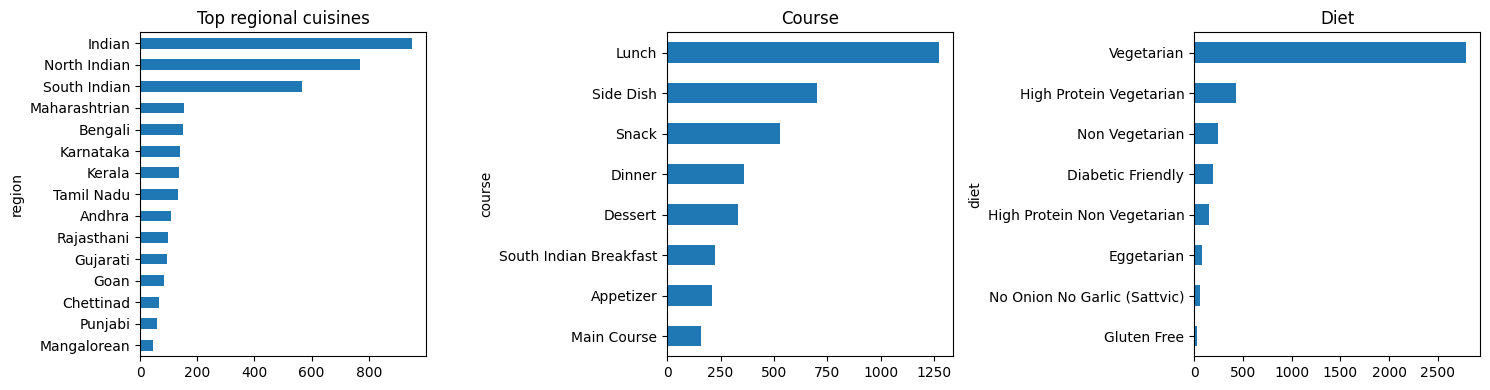

Gongura Chicken Curry 
 ['500 grams Chicken', '2 Onion - chopped', '1 Tomato - chopped', '4 Green Chillies - slit'] 
 To begin making Gongura Chicken Curry Recipe first prep all the ingredients and keep them aside. In a small pan, dry roast the methi seeds, coriander seeds, fennel seeds and red chillies for about 3 to 4 minutes on medium heat, until you notice the seeds crackling. Once done, turn off the heat and a


In [4]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
df.region.value_counts().head(15).sort_values().plot.barh(ax=ax[0], title="Top regional cuisines")
df.course.value_counts().head(8).sort_values().plot.barh(ax=ax[1], title="Course")
df.diet.value_counts().head(8).sort_values().plot.barh(ax=ax[2], title="Diet")
plt.tight_layout(); plt.show()
print(df.loc[3, "dish_name"], "\n", df.loc[3, "ingredients"][:4], "\n", df.loc[3, "steps"][:300])

---
# Experiment 1 — Study of NLP applications & Problem Statement

### 1.1 NLP applications studied and their relevance to cooking

| NLP application | What it does | Use in a recipe context |
|---|---|---|
| Machine translation | Translate text between languages | Translate regional recipes (e.g. Hindi ↔ English) |
| **Text categorization** | Assign labels to documents | Classify a recipe by cuisine / diet type |
| **Text summarization** | Shorten text keeping key ideas | Summarise long cooking instructions |
| Chatbot / Personal assistant | Conversational interface | "What can I cook with eggs and rice?" |
| **Plagiarism / duplicate detection** | Find copied or near-duplicate text | Detect duplicate recipes in a database |
| **Spelling & grammar checkers** | Correct typos | Fix "tomatoe" → "tomato" in ingredient search |
| **Sentiment / opinion analysis** | Detect positive / negative opinion | Analyse recipe reviews |
| Question answering | Answer questions from text | "How long do I bake the pizza?" |
| Tutoring systems | Teach step by step | Guided cooking mode |

Bold rows are implemented (fully or partly) in this project.

### 1.2 Problem Statement

> **Recipes are written as unstructured free text.** Ingredient quantities, cooking actions, durations and temperatures are buried inside sentences, which makes it hard to search, compare, categorise or summarise recipes automatically.
>
> **Aim:** Build a *Recipe Analyzer* that takes raw recipe text and automatically  
> (a) cleans and normalises it, (b) extracts structured information — ingredients with quantity/unit, cooking actions, time, temperature, equipment,  
> (c) predicts the cuisine, (d) summarises the method, (e) measures review sentiment, and (f) recommends similar recipes.

### 1.3 Objectives
1. Apply classic NLP pre-processing (tokenization, stop-word removal, stemming, lemmatization).
2. Use linguistic analysis (morphology, POS tagging, chunking) to find actions and ingredient phrases.
3. Build a domain-specific NER for recipes.
4. Use similarity measures for recommendation and typo-tolerant search.
5. Use a neural model (GRU/LSTM) to resolve ambiguous cooking words.

### 1.4 Input / Output
* **Input:** recipe title, ingredient lines, method text, optional review.
* **Output:** structured JSON-like report — parsed ingredients, actions, total time, temperature, difficulty, predicted cuisine, summary, sentiment, similar recipes.

---
# Experiment 2 — Text Pre-processing: Tokenization, Filtration & Script Validation
**Goal:** split raw text into sentences and words, filter unwanted tokens and verify that the text is in the expected script.

In [5]:
from nltk.tokenize import word_tokenize, sent_tokenize, RegexpTokenizer, WhitespaceTokenizer

sample = df.loc[0, "steps"]
print("SENTENCES:")
for i, s in enumerate(sent_tokenize(sample), 1):
    print(f"  {i}. {s}")

print("\nword_tokenize      :", word_tokenize(sample)[:14])
print("WhitespaceTokenizer:", WhitespaceTokenizer().tokenize(sample)[:14])
print("RegexpTokenizer    :", RegexpTokenizer(r"\w+").tokenize(sample)[:14])

SENTENCES:
  1. To begin making the Masala Karela Recipe,de-seed the karela and slice.
  2. Do not remove the skin as the skin has all the nutrients.
  3. Add the karela to the pressure cooker with 3 tablespoon of water, salt and turmeric powder and pressure cook for three whistles.
  4. Release the pressure immediately and open the lids.
  5. Keep aside.
  6. Heat oil in a heavy bottomed pan or a kadhai.
  7. Add cumin seeds and let it sizzle.
  8. Once the cumin seeds have sizzled, add onions and saute them till it turns golden brown in color.
  9. Add the karela, red chilli powder, amchur powder, coriander powder and besan.
  10. Stir to combine the masalas into the karela.
  11. Drizzle a little extra oil on the top and mix again.
  12. Cover the pan and simmer Masala Karela stirring occasionally until everything comes together well.
  13. Turn off the heat.
  14. Transfer Masala Karela into a serving bowl and serve.
  15. Serve Masala Karela along with Panchmel Dal and Phulka for 

**Filtration** — remove punctuation, numbers and symbols, and lower-case the tokens (quantities are handled separately later by the NER module).

In [6]:
def filter_tokens(tokens, min_len=2):
    out = []
    for t in tokens:
        t = t.lower()
        if t in string.punctuation:                       # punctuation
            continue
        if not re.fullmatch(r"[a-z]+(?:[-'][a-z]+)*", t):  # numbers, symbols, mixed junk
            continue
        if len(t) < min_len:                               # single letters
            continue
        out.append(t)
    return out

raw_tokens = word_tokenize(sample)
clean = filter_tokens(raw_tokens)
print(f"Raw tokens : {len(raw_tokens)}\nAfter filter: {len(clean)}")
print("Removed    :", sorted(set(raw_tokens) - set(clean)))

Raw tokens : 186
After filter: 159
Removed    : [',', '.', '3', 'Add', 'Cover', 'Dal', 'Do', 'Drizzle', 'Heat', 'Karela', 'Keep', 'Masala', 'Once', 'Panchmel', 'Phulka', 'Recipe', 'Release', 'Serve', 'Stir', 'To', 'Transfer', 'Turn', 'a']


**Script validation** — check the Unicode script of every character so that, for example, Devanagari or emoji tokens are detected in an English-only pipeline.

In [7]:
def char_script(ch):
    try:
        return unicodedata.name(ch).split()[0]     # 'LATIN', 'DEVANAGARI', ...
    except ValueError:
        return "UNKNOWN"

def token_script(token):
    scripts = Counter(char_script(c) for c in token if c.isalpha())
    return scripts.most_common(1)[0][0] if scripts else "NONE"

def validate_script(text, allowed=("LATIN",)):
    tokens = [t.strip(string.punctuation) for t in text.split()]
    report = [(t, token_script(t)) for t in tokens if t]
    invalid = [t for t, s in report if s not in allowed and s != "NONE"]
    return {"valid": not invalid, "invalid_tokens": invalid, "scripts": Counter(s for _, s in report)}

mixed = "Add 1 tsp हल्दी (turmeric) and 2 cups चावल (rice) with 1 tbsp घी 😋"
print(validate_script(mixed))
print(validate_script(df.loc[1, "steps"]))

def keep_allowed_script(text, allowed=("LATIN",)):
    text = unicodedata.normalize("NFKC", text)
    return " ".join(t for t in text.split() if token_script(t.strip(string.punctuation)) in (*allowed, "NONE"))

print("\nCleaned:", keep_allowed_script(mixed))

hindi_rows = df[df.hindi_name != ""]
print(f"\n{len(hindi_rows):,} dataset recipes carry a Devanagari name, e.g. {hindi_rows.hindi_name.iloc[0]!r}")
print(validate_script(hindi_rows.hindi_name.iloc[0]))

{'valid': False, 'invalid_tokens': ['हल्दी', 'चावल', 'घी'], 'scripts': Counter({'LATIN': 8, 'NONE': 4, 'DEVANAGARI': 3})}
{'valid': True, 'invalid_tokens': [], 'scripts': Counter({'LATIN': 112, 'NONE': 7})}

Cleaned: Add 1 tsp (turmeric) and 2 cups (rice) with 1 tbsp 😋

353 dataset recipes carry a Devanagari name, e.g. 'टमाटर पुलियोगरे'
{'valid': False, 'invalid_tokens': ['टमाटर', 'पुलियोगरे'], 'scripts': Counter({'DEVANAGARI': 2})}


---
# Experiment 3 — Stop-word Removal, Stemming & Lemmatization

In [8]:
from nltk.corpus import stopwords, wordnet
from nltk.stem import PorterStemmer, SnowballStemmer, LancasterStemmer, WordNetLemmatizer

stop_words = set(stopwords.words("english"))
# words like "up", "off", "over", "out", "not" carry meaning in recipes ("cut up", "not too hot")
KEEP = {"not", "no", "off", "up", "down", "over", "out", "until", "before", "after"}
recipe_stops = stop_words - KEEP

porter, snowball, lancaster = PorterStemmer(), SnowballStemmer("english"), LancasterStemmer()
lemmatizer = WordNetLemmatizer()

toks = filter_tokens(word_tokenize(df.loc[3, "steps"]))
no_stop = [t for t in toks if t not in recipe_stops]
print(f"{len(toks)} tokens -> {len(no_stop)} after stop-word removal")
print("Removed:", sorted(set(toks) - set(no_stop)))

268 tokens -> 178 after stop-word removal
Removed: ['about', 'all', 'and', 'are', 'for', 'in', 'into', 'it', 'of', 'on', 'once', 'some', 'the', 'them', 'there', 'to', 'when', 'will', 'with', 'you']


In [9]:
def wn_pos(tag):
    return {"J": wordnet.ADJ, "V": wordnet.VERB, "N": wordnet.NOUN, "R": wordnet.ADV}.get(tag[0], wordnet.NOUN)

words = ["chopped", "tomatoes", "baking", "leaves", "cooked", "stirring", "berries", "simmered", "grilled", "mixtures"]
tagged = nltk.pos_tag(words)
pd.DataFrame({
    "word": words,
    "Porter": [porter.stem(w) for w in words],
    "Snowball": [snowball.stem(w) for w in words],
    "Lancaster": [lancaster.stem(w) for w in words],
    "Lemma (POS-aware)": [lemmatizer.lemmatize(w, wn_pos(t)) for w, t in tagged],
})

,word,Porter,Snowball,Lancaster,Lemma (POS-aware)
0,chopped,chop,chop,chop,chop
1,tomatoes,tomato,tomato,tomato,tomato
2,baking,bake,bake,bak,bake
3,leaves,leav,leav,leav,leaf
4,cooked,cook,cook,cook,cook
5,stirring,stir,stir,stir,stir
6,berries,berri,berri,berry,berry
7,simmered,simmer,simmer,sim,simmer
8,grilled,grill,grill,gril,grilled
9,mixtures,mixtur,mixtur,mixt,mixture


Stemming is fast but can produce non-words (`berri`, `mixtur`); lemmatization returns real dictionary words, so the project uses **lemmatization** as the default.

In [10]:
DOMAIN_STOP = {"cup", "tsp", "tbsp", "teaspoon", "tablespoon", "minute", "hour", "min", "gram", "inch", "recipe", "begin", "making", "make"}   # units / boilerplate are not content words

def preprocess(text, stem=False, extra_stop=frozenset(), pos_aware=True):
    """tokenize -> filter -> POS -> stop-word removal -> lemmatize/stem
    pos_aware=False skips the (slow) POS tagger and lemmatizes as nouns - used for the whole corpus"""
    tokens = filter_tokens(word_tokenize(text.lower()))
    out = []
    for w, tag in (nltk.pos_tag(tokens) if pos_aware else [(t, "NN") for t in tokens]):
        if w in recipe_stops or w in extra_stop:
            continue
        out.append(porter.stem(w) if stem else lemmatizer.lemmatize(w, wn_pos(tag)))
    return out

print(preprocess(df.loc[0, "steps"]))
t0 = time.time()
df["clean_text"] = [" ".join(preprocess(t, extra_stop=DOMAIN_STOP, pos_aware=False)) for t in df["full_text"]]
print(f"cleaned {len(df):,} recipes in {time.time() - t0:.0f}s")
df[["dish_name", "clean_text"]].head(3)

['begin', 'make', 'masala', 'karela', 'recipe', 'de-seed', 'karela', 'slice', 'not', 'remove', 'skin', 'skin', 'nutrient', 'add', 'karela', 'pressure', 'cooker', 'tablespoon', 'water', 'salt', 'turmeric', 'powder', 'pressure', 'cook', 'three', 'whistle', 'release', 'pressure', 'immediately', 'open', 'lid', 'keep', 'aside', 'heat', 'oil', 'heavy', 'bottom', 'pan', 'kadhai', 'add', 'cumin', 'seed', 'let', 'sizzle', 'cumin', 'seed', 'sizzle', 'add', 'onion', 'saute', 'till', 'turn', 'golden', 'brown', 'color', 'add', 'karela', 'red', 'chilli', 'powder', 'amchur', 'powder', 'coriander', 'powder', 'besan', 'stir', 'combine', 'masalas', 'karela', 'drizzle', 'little', 'extra', 'oil', 'top', 'mix', 'cover', 'pan', 'simmer', 'masala', 'karela', 'stir', 'occasionally', 'until', 'everything', 'come', 'together', 'well', 'turn', 'off', 'heat', 'transfer', 'masala', 'karela', 'serve', 'bowl', 'serve', 'serve', 'masala', 'karela', 'along', 'panchmel', 'dal', 'phulka', 'weekday', 'meal', 'family']
cl

,dish_name,clean_text
0,Masala Karela,karela bitter pavakkai deseeded salt taste onion thinly sliced flour besan t...
1,Spicy Tomato Rice,cup rice cooked tomato teaspoon bc belle bhat powder salt per taste chickpea...
2,Ragi Semiya Upma,cup rice vermicelli noodle thin onion sliced carrot gajjar chopped green pea...


---
# Experiment 4 — Morphological Analysis & Word Generation
* **Analysis:** split a word into prefix, root and suffix and identify whether the change is *inflectional* (chop → chopped) or *derivational* (salt → unsalted).
* **Generation:** produce inflected forms from a root (rule-based, with irregular exceptions).

In [11]:
PREFIXES = ["over", "under", "pre", "un", "re", "dis", "non", "de"]
SUFFIXES = ["ness", "ment", "able", "less", "ful", "ing", "ies", "ed", "es", "er", "ly", "s"]
INFLECTIONAL = {"ing", "ed", "es", "ies", "s", "er"}

def analyze_word(word):
    w = word.lower()
    prefix = next((p for p in PREFIXES if w.startswith(p) and len(w) - len(p) >= 3), "")
    rest = w[len(prefix):]
    suffix = next((s for s in SUFFIXES if rest.endswith(s) and len(rest) - len(s) >= 3), "")
    root = rest[: len(rest) - len(suffix)] if suffix else rest
    lemma = wordnet.morphy(w, wordnet.VERB) or wordnet.morphy(w, wordnet.NOUN) or wordnet.morphy(w, wordnet.ADJ) or w
    kind = ("inflectional" if suffix in INFLECTIONAL else "derivational") if (suffix or prefix) else "root word"
    return dict(word=word, prefix=prefix or "-", root=root, suffix=suffix or "-", lemma=lemma, type=kind)

test_words = ["chopped", "tomatoes", "baking", "unsalted", "preheated", "stirring", "leaves", "overcooked", "seasoned", "flavourful", "gently"]
pd.DataFrame([analyze_word(w) for w in test_words])

,word,prefix,root,suffix,lemma,type
0,chopped,-,chopp,ed,chop,inflectional
1,tomatoes,-,tomato,es,tomato,inflectional
2,baking,-,bak,ing,bake,inflectional
3,unsalted,un,salt,ed,unsalted,inflectional
4,preheated,pre,heat,ed,preheat,inflectional
5,stirring,-,stirr,ing,stir,inflectional
6,leaves,-,leav,es,leave,inflectional
7,overcooked,over,cook,ed,overcook,inflectional
8,seasoned,-,season,ed,season,inflectional
9,flavourful,-,flavour,ful,flavourful,derivational


In [12]:
VOWELS = "aeiou"
IRREGULAR_VERBS = {  # base: (3rd person, past, past participle, gerund)
    "beat": ("beats", "beat", "beaten", "beating"),
    "cut": ("cuts", "cut", "cut", "cutting"),
    "put": ("puts", "put", "put", "putting"),
    "spread": ("spreads", "spread", "spread", "spreading"),
    "set": ("sets", "set", "set", "setting"),
    "hold": ("holds", "held", "held", "holding"),
}

def _double_final(v):
    """chop -> chopp, stir -> stirr (CVC + one syllable)"""
    groups = len(re.findall(r"[aeiou]+", v))
    return (len(v) >= 3 and groups == 1 and v[-1] not in VOWELS + "wxy"
            and v[-2] in VOWELS and v[-3] not in VOWELS)

def generate_verb_forms(v):
    if v in IRREGULAR_VERBS:
        s, p, pp, g = IRREGULAR_VERBS[v]
        return dict(base=v, third_person=s, past=p, past_participle=pp, gerund=g)
    if v.endswith(("s", "sh", "ch", "x", "z", "o")):        third = v + "es"
    elif v.endswith("y") and v[-2] not in VOWELS:            third = v[:-1] + "ies"
    else:                                                    third = v + "s"
    if v.endswith("e"):                                      past, ger = v + "d", v[:-1] + "ing"
    elif v.endswith("y") and v[-2] not in VOWELS:            past, ger = v[:-1] + "ied", v + "ing"
    elif _double_final(v):                                   past, ger = v + v[-1] + "ed", v + v[-1] + "ing"
    else:                                                    past, ger = v + "ed", v + "ing"
    return dict(base=v, third_person=third, past=past, past_participle=past, gerund=ger)

def pluralize(n):
    irregular = {"leaf": "leaves", "knife": "knives", "loaf": "loaves", "half": "halves"}
    if n in irregular: return irregular[n]
    if n.endswith(("s", "sh", "ch", "x", "z", "o")): return n + "es"     # tomato -> tomatoes
    if n.endswith("y") and n[-2] not in VOWELS:        return n[:-1] + "ies"  # berry -> berries
    return n + "s"

verbs = ["chop", "stir", "fry", "bake", "mix", "simmer", "boil", "mash", "beat", "cut", "spread", "peel"]
display(pd.DataFrame([generate_verb_forms(v) for v in verbs]))
print({n: pluralize(n) for n in ["tomato", "potato", "berry", "cherry", "leaf", "onion", "egg", "peach"]})

,base,third_person,past,past_participle,gerund
0,chop,chops,chopped,chopped,chopping
1,stir,stirs,stirred,stirred,stirring
2,fry,fries,fried,fried,frying
3,bake,bakes,baked,baked,baking
4,mix,mixes,mixed,mixed,mixing
5,simmer,simmers,simmered,simmered,simmering
6,boil,boils,boiled,boiled,boiling
7,mash,mashes,mashed,mashed,mashing
8,beat,beats,beat,beaten,beating
9,cut,cuts,cut,cut,cutting


{'tomato': 'tomatoes', 'potato': 'potatoes', 'berry': 'berries', 'cherry': 'cherries', 'leaf': 'leaves', 'onion': 'onions', 'egg': 'eggs', 'peach': 'peaches'}


---
# Experiment 5 — N-gram Language Model
We train uni/bi/tri-gram models on the cooking steps to (1) discover frequent phrases, (2) suggest the next word, (3) generate instruction-like sentences and (4) measure perplexity.

In [13]:
from nltk.util import ngrams
from nltk.lm import MLE, Laplace
from nltk.lm.preprocessing import padded_everygram_pipeline, pad_both_ends
from nltk.collocations import BigramCollocationFinder
from nltk.metrics import BigramAssocMeasures

sentences = [[w for w in word_tokenize(s.lower()) if w not in string.punctuation]
             for txt in df["steps"].sample(1500, random_state=42) for s in sent_tokenize(txt)]
random.shuffle(sentences)
cut = int(0.85 * len(sentences))
train_s, test_s = sentences[:cut], sentences[cut:]
print(len(train_s), "train sentences,", len(test_s), "test sentences")

# --- most frequent n-grams
flat = [w for s in train_s for w in s]
for n in (2, 3):
    top = Counter(ngrams(flat, n)).most_common(6)
    print(f"\nTop {n}-grams:", [(" ".join(g), c) for g, c in top])

18258 train sentences, 3222 test sentences

Top 2-grams: [('in a', 1900), ('add the', 1877), ('in the', 1230), ('along with', 1150), ('to begin', 1036), ('begin making', 1027)]

Top 3-grams: [('to begin making', 983), ('begin making the', 782), ('turn off the', 611), ('off the heat', 485), ('oil in a', 451), ('and mix well', 314)]


In [14]:
def train_lm(n, cls=Laplace):
    data, vocab = padded_everygram_pipeline(n, train_s)
    lm = cls(n); lm.fit(data, vocab); return lm

def perplexity(lm, n):
    grams = [g for s in test_s for g in ngrams(pad_both_ends(s, n=n), n)]
    return lm.perplexity(grams)

models_ = {n: train_lm(n) for n in (1, 2, 3)}
for n, lm in models_.items():
    print(f"{n}-gram (Laplace) perplexity on held-out sentences: {perplexity(lm, n):8.1f}")
print("(higher-order models are sparser on a corpus this small, so their perplexity is higher; it drops with more text)")

# --- next-word suggestion
bigram_counts = defaultdict(Counter)
for s in train_s:
    for a, b in ngrams(s, 2): bigram_counts[a][b] += 1

def suggest_next(word, k=4):
    c = bigram_counts.get(word.lower())
    return [(w, round(v / sum(c.values()), 2)) for w, v in c.most_common(k)] if c else []

for w in ["preheat", "stir", "until", "cook", "add"]:
    print(f"{w:8s} ->", suggest_next(w))

1-gram (Laplace) perplexity on held-out sentences:    377.7
2-gram (Laplace) perplexity on held-out sentences:    230.9
3-gram (Laplace) perplexity on held-out sentences:    664.3
(higher-order models are sparser on a corpus this small, so their perplexity is higher; it drops with more text)
preheat  -> [('the', 0.66), ('a', 0.19), ('oven', 0.07), ('an', 0.02)]
stir     -> [('in', 0.26), ('well', 0.16), ('fry', 0.11), ('and', 0.09)]
until    -> [('the', 0.36), ('it', 0.15), ('they', 0.09), ('you', 0.07)]
cook     -> [('for', 0.31), ('the', 0.18), ('till', 0.11), ('until', 0.1)]
add      -> [('the', 0.33), ('in', 0.07), ('a', 0.04), ('mustard', 0.03)]


• heat a pressure cooker for about 10 mins or till it
• heat a grill pan and add it to sit for 15
• heat ghee in a tempering pan with a lid to cook
• heat oil in a heavy bottoemed pan and roast on medium

Top PMI collocations: [('abobora', 'branca'), ('adadiya', 'pak'), ('anardan', 'chetin'), ('ani', 'maska'), ('bilahir', 'tok'), ('boodida', 'gummadikaya'), ('chhoti', 'aalur'), ('chhotu', 'alur'), ('chokh', 'vangun'), ('chotti', 'aloor')]


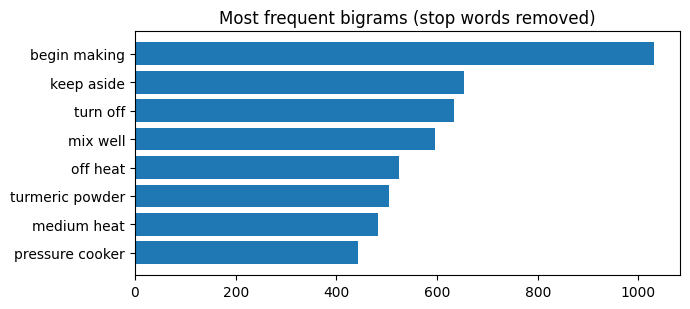

In [15]:
def generate(lm, seed_words=(), n_words=12, seed=7):
    out = list(lm.generate(n_words, text_seed=list(seed_words), random_seed=seed))
    words = [w for w in out if w not in ("<s>", "</s>")]
    return " ".join(list(seed_words) + words)

trigram = train_lm(3, MLE)
for sd in range(3, 7):
    print("•", generate(trigram, ["heat"], 10, seed=sd))

# --- collocations: which words stick together (ingredient pairs, cooking phrases)
finder = BigramCollocationFinder.from_words(flat)
finder.apply_freq_filter(2)
finder.apply_word_filter(lambda w: w in recipe_stops or len(w) < 3)
print("\nTop PMI collocations:", finder.nbest(BigramAssocMeasures().pmi, 10))

top_bi = Counter(b for b in ngrams([w for w in flat if w not in recipe_stops], 2)).most_common(8)
plt.figure(figsize=(7, 3.2)); plt.barh([" ".join(g) for g, _ in top_bi][::-1], [c for _, c in top_bi][::-1])
plt.title("Most frequent bigrams (stop words removed)"); plt.tight_layout(); plt.show()

---
# Experiment 6 — POS Tagging (study of different taggers)
We compare taggers on the Penn Treebank sample: **Default → Regexp → Unigram → Bigram → Trigram (with backoff)** and NLTK's pre-trained **Averaged Perceptron** tagger. The best one is then used on recipe steps to pull out cooking actions.

,accuracy
Default (NN),0.157
Regexp,0.262
Unigram,0.896
Bigram+backoff,0.906
Trigram+backoff,0.906
Averaged Perceptron,0.959


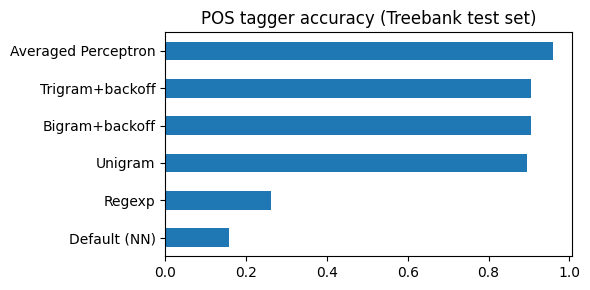

In [16]:
from nltk.corpus import treebank

clean_sents = [[(w, t) for w, t in s if t != "-NONE-"] for s in treebank.tagged_sents()]
split = int(0.9 * len(clean_sents))
tr, te = clean_sents[:split], clean_sents[split:]

patterns = [(r".*ing$", "VBG"), (r".*ed$", "VBD"), (r".*es$", "VBZ"), (r".*ly$", "RB"),
            (r".*s$", "NNS"), (r"^-?[0-9]+(\.[0-9]+)?$", "CD"), (r".*", "NN")]
default = nltk.DefaultTagger("NN")
regexp  = nltk.RegexpTagger(patterns, backoff=default)
unigram = nltk.UnigramTagger(tr, backoff=regexp)
bigram  = nltk.BigramTagger(tr, backoff=unigram)
trigram_t = nltk.TrigramTagger(tr, backoff=bigram)

def tagger_acc(t, sents):
    return t.accuracy(sents) if hasattr(t, "accuracy") else t.evaluate(sents)

def perceptron_acc(sents):
    ok = tot = 0
    for s in sents:
        pred = nltk.pos_tag([w for w, _ in s])
        ok += sum(p[1] == g[1] for p, g in zip(pred, s)); tot += len(s)
    return ok / tot

res = {"Default (NN)": tagger_acc(default, te), "Regexp": tagger_acc(regexp, te),
       "Unigram": tagger_acc(unigram, te), "Bigram+backoff": tagger_acc(bigram, te),
       "Trigram+backoff": tagger_acc(trigram_t, te), "Averaged Perceptron": perceptron_acc(te[:300])}
res_df = pd.Series(res, name="accuracy").round(3).to_frame()
display(res_df)
res_df["accuracy"].plot.barh(figsize=(6, 3), title="POS tagger accuracy (Treebank test set)"); plt.tight_layout(); plt.show()

Now tag real recipe steps. Recipes are written in the **imperative** ("Mix the flour…"), which general taggers often mis-tag at the start of a sentence, so we lower-case the text and combine the tagger output with a cooking-verb lexicon.

[('to', 'TO'), ('begin', 'VB'), ('making', 'VBG'), ('Gongura', 'NNP'), ('Chicken', 'NNP'), ('Curry', 'NNP'), ('Recipe', 'NNP'), ('first', 'RB'), ('prep', 'VBZ'), ('all', 'PDT'), ('the', 'DT'), ('ingredients', 'NNS'), ('and', 'CC'), ('keep', 'VB'), ('them', 'PRP'), ('aside', 'RB'), ('.', '.'), ('in', 'IN')]

Actions in Gongura Chicken Curry -> ['roast', 'heat', 'blend', 'add', 'chop', 'saute', 'cook', 'make', 'grind', 'check', 'transfer', 'serve']


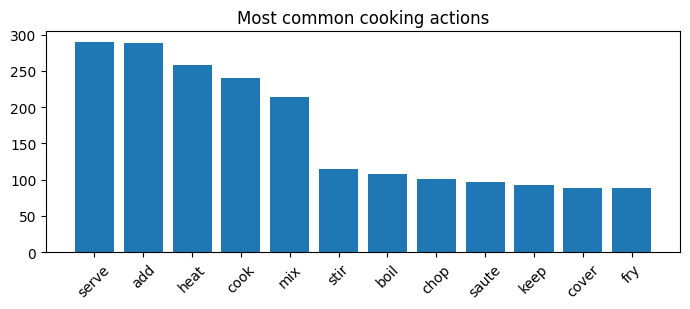

In [17]:
COOKING_VERBS = set("""add bake blanch blend boil bring chill chop coat combine cook cover cut dice drain drizzle fold fry
garnish grate grill heat knead layer marinate mash mix parboil peel pour preheat reduce remove rest roast roll saute
scramble season serve shred simmer slice soak spread sprinkle squeeze stir toss whisk finish fill melt steam toast
stuff pound crush steep beat crack grind temper splutter sizzle ferment puree crumble""".split())

def pos_tag_text(text):
    return [(w, t) for s in sent_tokenize(text) for w, t in nltk.pos_tag(word_tokenize(s[0].lower() + s[1:]))]

def extract_actions(text):
    """cooking verbs from the lexicon + sentence-initial verbs (imperatives) found by the POS tagger"""
    seen, actions = set(), []
    for s in sent_tokenize(text):
        for i, (w, t) in enumerate(nltk.pos_tag(word_tokenize(s[0].lower() + s[1:]))):
            base = lemmatizer.lemmatize(w, wordnet.VERB)
            if (base in COOKING_VERBS or (i == 0 and t.startswith("VB") and w.isalpha())) and base not in seen:
                seen.add(base); actions.append(base)
    return actions

txt = df.loc[3, "steps"]
print(pos_tag_text(txt)[:18])
print("\nActions in", df.loc[3, "title"], "->", extract_actions(txt))

verb_counts = Counter(v for s in df["steps"].head(300) for v in extract_actions(s))
top = verb_counts.most_common(12)
plt.figure(figsize=(7, 3.2)); plt.bar([v for v, _ in top], [c for _, c in top])
plt.xticks(rotation=45); plt.title("Most common cooking actions"); plt.tight_layout(); plt.show()

---
# Experiment 7 — Chunking: importance of features and training-set size
We train an NP (noun-phrase) chunker on the **CoNLL-2000** corpus with a Naive-Bayes classifier and study how

1. the **feature set** (POS only → +context → +POS pairs → +words) and  
2. the **amount of training data**

change the F1 score. The best setup is then compared with a hand-written regular-expression grammar on recipe text.

In [18]:
from nltk.corpus import conll2000

train_sents = conll2000.chunked_sents("train.txt", chunk_types=["NP"])
test_sents  = conll2000.chunked_sents("test.txt",  chunk_types=["NP"])[:300]
print(len(train_sents), "training sentences available;", len(test_sents), "used for testing")

def make_features(level):
    """level 1: POS | 2: +prev/next POS | 3: +POS pairs | 4: +words"""
    def feats(tokens, index, history):
        word, pos = tokens[index]
        prevw, prevp = ("<START>", "<START>") if index == 0 else tokens[index - 1]
        nextw, nextp = ("<END>", "<END>") if index == len(tokens) - 1 else tokens[index + 1]
        f = {"pos": pos}
        if level >= 2: f.update(prevpos=prevp, nextpos=nextp)
        if level >= 3: f.update(prevpos_pos=f"{prevp}+{pos}", pos_nextpos=f"{pos}+{nextp}")
        if level >= 4: f.update(word=word, prevword=prevw)
        return f
    return feats

class ChunkParser(nltk.ChunkParserI):
    def __init__(self, sents, feature_fn):
        data = [[((w, t), c) for w, t, c in nltk.chunk.tree2conlltags(s)] for s in sents]
        self.tagger = nltk.ClassifierBasedTagger(train=data, feature_detector=feature_fn)
    def parse(self, tagged_sent):
        tagged = self.tagger.tag(tagged_sent)
        return nltk.chunk.conlltags2tree([(w, t, c) for ((w, t), c) in tagged])

def evaluate_chunker(parser, gold):
    score = parser.accuracy(gold) if hasattr(parser, "accuracy") else parser.evaluate(gold)
    return score.f_measure()

8936 training sentences available; 300 used for testing


done in 6s


,POS only,+ prev/next POS,+ POS pairs,+ words
training sentences,,,,
200,0.773,0.854,0.871,0.873
500,0.837,0.861,0.876,0.880
1000,0.836,0.861,0.871,0.881
2000,0.836,0.859,0.875,0.884


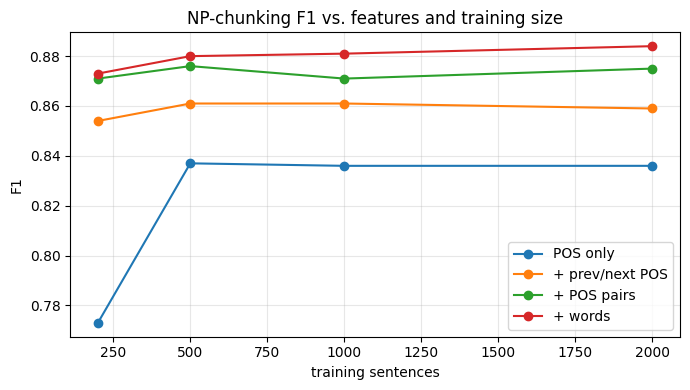

In [19]:
import time
sizes = [200, 500, 1000, 2000]
levels = {1: "POS only", 2: "+ prev/next POS", 3: "+ POS pairs", 4: "+ words"}
results = {name: [] for name in levels.values()}

t0 = time.time()
for lvl, name in levels.items():
    for n in sizes:
        parser = ChunkParser(train_sents[:n], make_features(lvl))
        results[name].append(evaluate_chunker(parser, test_sents))
print(f"done in {time.time() - t0:.0f}s")

res7 = pd.DataFrame(results, index=sizes).round(3); res7.index.name = "training sentences"
display(res7)
res7.plot(marker="o", figsize=(7, 4), title="NP-chunking F1 vs. features and training size")
plt.ylabel("F1"); plt.grid(alpha=.3); plt.tight_layout(); plt.show()

**Observation:** adding *context* (previous/next POS) gives the largest jump (about +2 to +8 F1 points). POS pairs and word features add smaller gains. Extra training data helps a lot at first (200 → 500 sentences) and then flattens for simple feature sets, while richer feature sets keep improving slowly — so both *good features* and *enough data* matter, and features matter more once the data is moderate.

In [20]:
# Best model applied to recipe text (POS tags come from NLTK's tagger) ...
best_parser = ChunkParser(train_sents[:2000], make_features(3))

def chunk_np(sentence):
    tagged = nltk.pos_tag(word_tokenize(sentence))
    tree = best_parser.parse(tagged)
    return [" ".join(w for w, _ in st.leaves()) for st in tree if hasattr(st, "label") and st.label() == "NP"]

s = "Add the cream and grilled chicken and simmer for 8 minutes."
print("ML chunker NPs :", chunk_np(s))

# ... versus a rule-based grammar tailored to recipes
grammar = r"""
  NP:  {<CD>?<JJ|VBN|VBG>*<NN.*>+}       # (8) (grilled) chicken
  ACT: {<VB|VBP>+<DT>?<NP>?}              # action + object
  DUR: {<IN><CD><NNS>}                    # for 8 minutes
"""
rx = nltk.RegexpParser(grammar)
tree = rx.parse(nltk.pos_tag(word_tokenize(s.lower())))
for st in tree.subtrees(lambda t: t.label() in {"NP", "DUR"}):
    print(f"{st.label():4s}:", " ".join(w for w, _ in st.leaves()))

ML chunker NPs : ['the cream', 'chicken', 'simmer', '8 minutes']
NP  : cream
NP  : chicken
NP  : simmer
NP  : 8 minutes


---
# Experiment 8 — Named Entity Recognition
1. Try NLTK's built-in NER (trained on news: PERSON / ORGANIZATION / GPE).  
2. Build a **domain-specific recipe NER** with regular expressions + a gazetteer (ingredient dictionary learned from the dataset, including Indian names such as *jeera, haldi, dhania*) + rules, recognising  
   `INGREDIENT · DURATION · TEMPERATURE · EQUIPMENT (kadhai, tawa, cooker…) · COOKING_METHOD`, and parse ingredient lines into `quantity · unit · name`.

In [21]:
from nltk import ne_chunk, pos_tag

def nltk_entities(text):
    tree = ne_chunk(pos_tag(word_tokenize(text)))
    return [(" ".join(w for w, _ in st.leaves()), st.label()) for st in tree if hasattr(st, "label")]

news = "Chef Sanjeev Kapoor shared this Hyderabadi biryani recipe from Hyderabad with Times of India in Mumbai."
print(nltk_entities(news))
print(nltk_entities("Add jeera and haldi to the kadhai and cook for 10 minutes."))   # general NER knows nothing about food

[('Chef', 'PERSON'), ('Sanjeev Kapoor', 'PERSON'), ('Hyderabad', 'GPE'), ('Times', 'PERSON'), ('India', 'GPE'), ('Mumbai', 'GPE')]
[('Add', 'GPE')]


As expected, the general-purpose model finds people and places but nothing useful in a cooking instruction. We need a domain NER.

In [22]:
# ---------- patterns ----------
QTY  = r"(?:\d+[\s-]\d+/\d+|\d+/\d+|\d+(?:\.\d+)?|[½¼¾⅓⅔])"
UNIT = r"(?:cups?|tsp|tbsp|teaspoons?|tablespoons?|kgs?|kilograms?|grams?|gms?|g|ml|litres?|liters?|l|oz|lbs?|cans?|cloves?|pinch(?:es)?|inch(?:es)?|sprigs?|bunch(?:es)?|pods?|handful|dash|slices?|pieces?|stalks?)"
NUMW = "forty-five|one|two|three|four|five|six|seven|eight|nine|ten|eleven|twelve|fifteen|twenty|thirty|forty|sixty|half|quarter"
WORD2NUM = dict(one=1, two=2, three=3, four=4, five=5, six=6, seven=7, eight=8, nine=9, ten=10, eleven=11, twelve=12,
                fifteen=15, twenty=20, thirty=30, forty=40, sixty=60, half=.5, quarter=.25); WORD2NUM["forty-five"] = 45
_num = rf"(?:{QTY}|{NUMW})"
TIME_RE = re.compile(rf"\b(?:{_num}(?:\s*(?:-|to)\s*{_num})?\s*(?:seconds?|secs?|minutes?|mins?|hours?|hrs?)|(?:half|quarter)\s+(?:an?\s+)?hour)\b", re.I)
TEMP_RE = re.compile(r"\b\d{2,3}\s*(?:°\s*[CF]|degrees(?:\s*(?:Celsius|Fahrenheit|C|F))?|[CF]\b)")
ING_LINE = re.compile(rf"^\s*(?P<qty>{QTY})?\s*(?P<unit>{UNIT}\b)?\s*(?P<name>.+?)\s*$", re.I)

DESCRIPTORS = {"fresh", "ripe", "large", "active", "dry", "warm", "plain", "grated", "shredded", "roasted", "dried", "cooked",
               "chopped", "can", "all", "purpose", "boneless", "cubes", "cube", "sliced", "diced", "small", "medium", "big",
               "thin", "thinly", "finely", "soaked", "boiled", "peeled", "washed", "raw", "optional", "adjust", "required", "taste"}
EQUIPMENT = {"oven", "pan", "wok", "pot", "bowl", "grill", "skillet", "blender", "kadhai", "kadai", "tawa", "tava",
             "cooker", "vessel", "steamer", "grinder", "mixer", "tadka"}
AMBIGUOUS_VERBS = {"heat", "top", "warm", "cover", "rest", "season", "roll", "finish"}   # also nouns/adjectives

def qty_to_float(q):
    if not q: return None
    q = q.strip().translate(str.maketrans({"½": " 1/2", "¼": " 1/4", "¾": " 3/4", "⅓": " 1/3", "⅔": " 2/3"})).replace("-", " ")
    return float(sum(Fraction(p) for p in q.split()))

def parse_ingredient(line):
    """'3 tablespoon Gram flour (besan) - sifted' -> qty 3, unit tablespoon, name 'gram flour', alias 'besan', note 'sifted'"""
    m = ING_LINE.match(line)
    main, _, note = m["name"].partition(" - ")
    alias = " ".join(re.findall(r"\(([^)]*)\)", main))
    core = re.sub(r"\([^)]*\)", " ", main).lower()
    words = [w for w in re.findall(r"[a-z]+", core) if w not in DESCRIPTORS]
    return dict(raw=line, quantity=qty_to_float(m["qty"]), unit=(m["unit"] or "").lower() or None,
                name=" ".join(words) or core.strip(), alias=alias.lower() or None, note=note.strip() or None)

def to_minutes(span):
    s = span.lower()
    if re.search(r"(?:half|quarter)\s+(?:an?\s+)?hour", s):
        return 30.0 if "half" in s else 15.0
    vals = [WORD2NUM[x] if x in WORD2NUM else qty_to_float(x) for x in re.findall(rf"{QTY}|\b(?:{NUMW})\b", s)]
    v = sum(vals) / len(vals) if vals else 0.0
    unit = s.split()[-1]
    return v * (60 if unit.startswith("h") else 1 / 60 if unit.startswith("sec") else 1)

print(pd.DataFrame([parse_ingredient(l) for l in df.loc[3, "ingredients"][:6] + ["1-1/2 cup Water", "½ cup Sugar", "Salt - to taste"]]).drop(columns="raw"))
print([(t, round(to_minutes(t), 1)) for t in ["10 to 12 minutes", "1 hour", "half an hour", "five mins", "1-1/2 hours"]])

   quantity    unit            name alias            note
0     500.0   grams         chicken  None            None
1       2.0    None           onion  None         chopped
2       1.0    None          tomato  None         chopped
3       4.0    None  green chillies  None            slit
4       1.0    inch          ginger  None  finely chopped
5       6.0  cloves          garlic  None  finely chopped
6       1.5     cup           water  None            None
7       0.5     cup           sugar  None            None
8       NaN    None            salt  None        to taste
[('10 to 12 minutes', 11.0), ('1 hour', 60.0), ('half an hour', 30.0), ('five mins', 5.0), ('1-1/2 hours', 90.0)]


In [23]:
# ---------- parse every ingredient line once, then learn the ingredient gazetteer from the data ----------
df["parsed"] = df["ingredients"].apply(lambda L: [parse_ingredient(l) for l in L])

tok_counts = Counter()
for plist in df["parsed"]:
    for p in plist:
        for w in set(re.findall(r"[a-z]+", p["name"] + " " + (p["alias"] or ""))):
            tok_counts[lemmatizer.lemmatize(w)] += 1

NOT_INGREDIENT = {"cup", "tsp", "tbsp", "teaspoon", "tablespoon", "gram", "inch", "recipe", "needed", "plus", "extra", "use",
                  "few", "piece", "more", "little", "approx", "about", "and", "for", "the", "with", "into", "each", "per", "or"}
NOT_INGREDIENT |= {"make", "hot", "cold", "brown", "light", "dark", "heavy", "thick", "good", "store", "bought", "packet",
                   "homemade", "ready", "leftover", "tender", "ingredient", "dish", "size", "bite", "half", "whole"}
VERB_STEMS = {porter.stem(v) for v in COOKING_VERBS}
ING_TOKENS = {w for w, c in tok_counts.items() if c >= 5 and len(w) > 2 and w not in recipe_stops
              and w not in NOT_INGREDIENT and porter.stem(w) not in VERB_STEMS}
print(f"Gazetteer: {len(ING_TOKENS):,} ingredient words learned from {sum(len(p) for p in df.parsed):,} ingredient lines")
print("most common:", [w for w, _ in tok_counts.most_common(25)])

Gazetteer: 467 ingredient words learned from 50,502 ingredient lines
most common: ['powder', 'seed', 'chilli', 'salt', 'leaf', 'oil', 'red', 'green', 'coriander', 'dhania', 'turmeric', 'sunflower', 'cumin', 'onion', 'haldi', 'jeera', 'ginger', 'garlic', 'mustard', 'dal', 'flour', 'curry', 'masala', 'coconut', 'tomato']


### Palak Paneer Bhurji - North Indian
To make the [Palak Paneer|ING] Bhurji recipe, firstly make [paneer|ING]. You can also buy [cheese|ING] from outside. Steal the [cheese|ING] and keep it aside. Now heat [oil|ING] in a [pan|EQU]. [Add|COO] [cumin seeds|ING] and let it crackle. After the [cumin seeds|ING] crackle, [add|COO] [ginger|ING], [garlic|ING], [green chillies|ING], [onions|ING] and [cook|COO] them till the [onions|ING] turn light brown. Now [add|COO] [tomatoes|ING] and [cook|COO] till they become soft. [Add|COO] the [spinach|ING] and [cook|COO] until the [spinach|ING] is cooked. Now [add|COO] [red chili powder|ING], [garam masala powder|ING], [mango powder|ING], [paneer|ING] and [mix|COO] well. [Add|COO] the [butter|ING] and [cook|COO] for [3 to 4 minutes|DUR]. After [cooking|COO], turn off the gas and [serve|COO] hot. [Serve|COO] the [spinach paneer|ING] bhurji with [dal|ING] makhni, [boondi|ING] raita and phulka for dinner.

### Aar Macher Jhol - Bengali
To begin making the

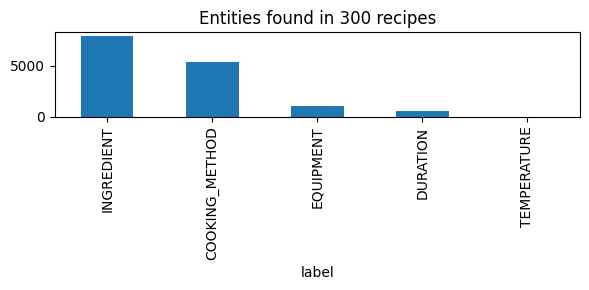

In [24]:
COOK_STEMS = {porter.stem(v) for v in COOKING_VERBS}

def recipe_ner_spans(text):
    """returns [(start, end, surface, LABEL)] in text order"""
    found = []
    for label, rx in (("TEMPERATURE", TEMP_RE), ("DURATION", TIME_RE)):
        found += [(m.start(), m.end(), m.group(), label) for m in rx.finditer(text)]
    taken = [(s, e) for s, e, *_ in found]
    words = [m for m in re.finditer(r"[A-Za-z]+", text) if not any(s <= m.start() < e for s, e in taken)]
    for i, m in enumerate(words):
        w = m.group().lower()
        before = text[:m.start()].rstrip()
        sent_start = (not before) or before[-1] in ".!?"
        prev_w = words[i - 1].group().lower() if i else ""
        if lemmatizer.lemmatize(w) in EQUIPMENT and not (sent_start and porter.stem(w) in COOK_STEMS):   # "Grill the chicken" = verb
            found.append((m.start(), m.end(), m.group(), "EQUIPMENT"))
        elif porter.stem(w) in COOK_STEMS and not (w.endswith("ed") and not sent_start):
            if w not in AMBIGUOUS_VERBS or sent_start or prev_w in {"and", "then"}:
                found.append((m.start(), m.end(), m.group(), "COOKING_METHOD"))
        elif lemmatizer.lemmatize(w) in ING_TOKENS:
            found.append((m.start(), m.end(), m.group(), "INGREDIENT"))
    found.sort()
    merged = []                                  # merge adjacent tokens of one label: "garam" "masala", "mixer" "grinder"
    for s, e, surf, lab in found:
        if merged and lab in ("INGREDIENT", "EQUIPMENT") and merged[-1][3] == lab and text[merged[-1][1]:s].strip() == "":
            ps = merged[-1][0]; merged[-1] = (ps, e, text[ps:e], lab)
        else:
            merged.append((s, e, surf, lab))
    return merged

def recipe_ner(text):
    return [(surf, lab) for _, _, surf, lab in recipe_ner_spans(text)]

def show_entities(text):
    colors = {"INGREDIENT": "\033[92m", "COOKING_METHOD": "\033[94m", "DURATION": "\033[93m",
              "TEMPERATURE": "\033[91m", "EQUIPMENT": "\033[95m"}
    out, pos = "", 0
    for s, e, surf, lab in recipe_ner_spans(text):
        out += text[pos:s] + f"{colors[lab]}[{surf}|{lab[:3]}]\033[0m"
        pos = e
    print(out + text[pos:])

i_demo = df.index[df.dish_name.str.contains("Palak Paneer", case=False)][0]
print("###", df.dish_name[i_demo], "-", df.region[i_demo]); show_entities(df.steps[i_demo])
print("\n###", df.dish_name[10], "-", df.region[10]); show_entities(df.steps[10])

ents = pd.DataFrame([(r.dish_name, s, l) for r in df.head(300).itertuples() for s, l in recipe_ner(r.steps)], columns=["recipe", "entity", "label"])
ents["label"].value_counts().plot.bar(figsize=(6, 3), title="Entities found in 300 recipes"); plt.tight_layout(); plt.show()

---
# Experiment 9 — Text Similarity Recognizer
Three views of similarity are combined and turned into search features over the whole dataset:

| Method | Level | Used for |
|---|---|---|
| **TF-IDF + cosine** | whole recipe text | "recipes like this one" |
| **Jaccard** | set of ingredients | ingredient overlap / duplicate detection |
| **Levenshtein (edit distance)** | characters | typo-tolerant ingredient search ("panneer" → paneer) |
| **Character n-gram TF-IDF** | dish names | finding a dish by its Indian / English / Hindi name even if spelled differently |

In [25]:
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

tfidf = TfidfVectorizer(ngram_range=(1, 2), min_df=3, max_df=0.5, sublinear_tf=True)
X = tfidf.fit_transform(df["clean_text"])
print("recipe TF-IDF matrix:", X.shape)

# ingredient identity = cleaned ingredient names ("gram flour"), ingredient words = gazetteer words
def ingredient_features(plist):
    names = {p["name"] for p in plist if p["name"]}
    toks = {lemmatizer.lemmatize(w) for p in plist for w in re.findall(r"[a-z]+", p["name"] + " " + (p["alias"] or ""))} & ING_TOKENS
    return sorted(names), sorted(toks)

feats = df["parsed"].apply(ingredient_features)
df["ing_names"], df["ing_tokens"] = feats.str[0], feats.str[1]

B = CountVectorizer(analyzer=lambda L: L, binary=True).fit_transform(df["ing_names"]).tocsr()
tok_cv = CountVectorizer(analyzer=lambda L: L, binary=True)
T = tok_cv.fit_transform(df["ing_tokens"]).tocsr()
TOK_INDEX = {w: i for i, w in enumerate(tok_cv.get_feature_names_out())}
B_sizes = np.asarray(B.sum(1)).ravel()

def jaccard_row(i):
    inter = (B @ B[i].T).toarray().ravel()
    return inter / (B_sizes + B_sizes[i] - inter)

recipe TF-IDF matrix: (4014, 31639)


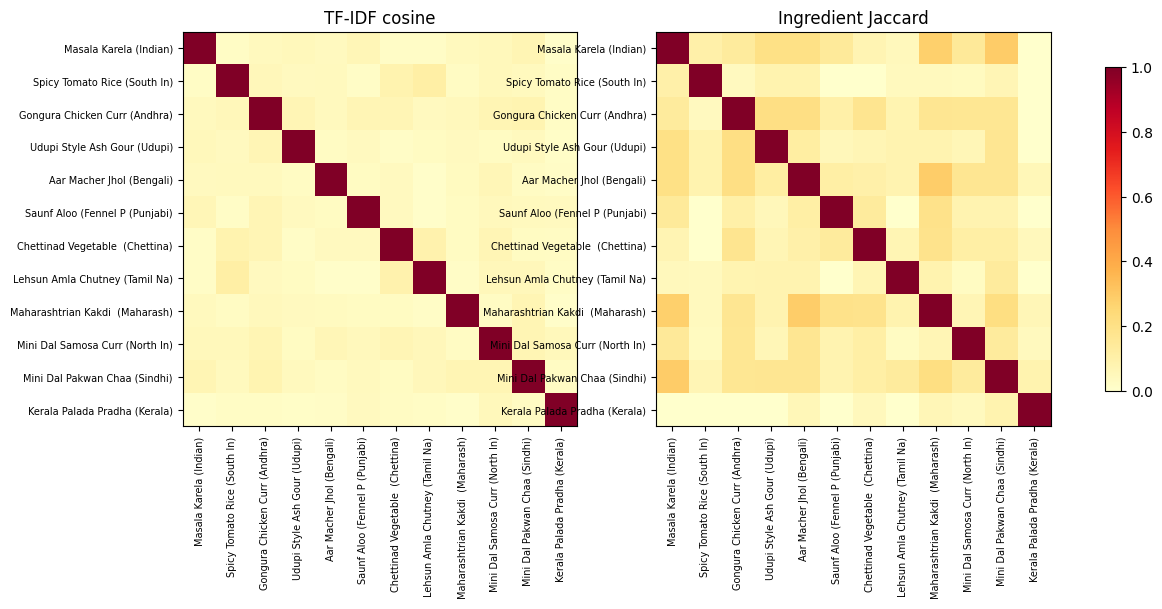

In [26]:
# heat-maps for 12 recipes from 12 different regions
demo_idx = list(df.groupby("region").head(1).index[:12])
cos_s = cosine_similarity(X[demo_idx])
jac_s = np.array([[jaccard_row(i)[j] for j in demo_idx] for i in demo_idx])
labels = [f"{df.dish_name[i][:20]} ({df.region[i][:8]})" for i in demo_idx]

fig, ax = plt.subplots(1, 2, figsize=(14, 6))
for a, M, t in zip(ax, (cos_s, jac_s), ("TF-IDF cosine", "Ingredient Jaccard")):
    im = a.imshow(M, cmap="YlOrRd", vmin=0, vmax=1); a.set_title(t)
    a.set_xticks(range(len(demo_idx))); a.set_yticks(range(len(demo_idx)))
    a.set_xticklabels(labels, rotation=90, fontsize=7); a.set_yticklabels(labels, fontsize=7)
plt.colorbar(im, ax=ax, shrink=.7); plt.show()

In [27]:
# ---- find a dish by name (Indian / English / Hindi); character n-grams tolerate spelling variants
name_text = (df.dish_name + " " + df.english_desc + " " + df.hindi_name).str.lower()
name_vec = TfidfVectorizer(analyzer="char_wb", ngram_range=(2, 4))
NAME_M = name_vec.fit_transform(name_text)

def find_dishes(query, k=5):
    s = cosine_similarity(name_vec.transform([query.lower()]), NAME_M).ravel()
    top = np.argsort(-s)[:k]
    out = df.loc[top, ["dish_name", "english_desc", "hindi_name", "region", "course"]].copy()
    out["match"] = s[top].round(2)
    return out

display(find_dishes("masala dosa", 4))
display(find_dishes("बिरयानी", 3))          # Devanagari query
display(find_dishes("rajma chawal", 3))

# ---- recipes similar to a given recipe (cosine on text + Jaccard on ingredients)
def similar_recipes(query, k=5, w_cos=0.6):
    i = find_dishes(query, 1).index[0] if isinstance(query, str) else query
    score = w_cos * cosine_similarity(X[i], X).ravel() + (1 - w_cos) * jaccard_row(i)
    order = [j for j in np.argsort(-score) if j != i][:k]
    print(f"Recipes similar to: {df.dish_name[i]} ({df.region[i]})")
    return pd.DataFrame({"recipe": df.dish_name[order].values, "region": df.region[order].values,
                         "cosine": cosine_similarity(X[i], X[order]).ravel().round(2),
                         "jaccard": jaccard_row(i)[order].round(2), "score": score[order].round(2)})

display(similar_recipes("Palak Paneer"))
display(similar_recipes("Medu Vada"))

,dish_name,english_desc,hindi_name,region,course,match
915,Sagu Masala Dosa,Sagu Masala Dosa,,Karnataka,South Indian Breakfast,0.75
2038,Egg Roast Masala Dosa,With Moong Dal Dosa Batter,,South Indian,South Indian Breakfast,0.67
2034,Mysore Masala Dosa Made With Ragi Dosa Batter,Mysore Masala Dosa Made With Ragi Dosa Batter,,Karnataka,South Indian Breakfast,0.64
1642,Kanchipuram Masala Dosa Recipe With Soya Dosa Batter,Kanchipuram Masala Dosa Recipe With Soya Dosa Batter,,South Indian,South Indian Breakfast,0.60


,dish_name,english_desc,hindi_name,region,course,match
3436,Paneer Biryani,Paneer Biryani,पनीर बिरयानी,Indian,Lunch,0.51
2531,Laal Maas Biryani,Laal Maas Biryani,लाल मास बिरयानी,Rajasthani,Main Course,0.40
127,Biryani Masala Powder,Biryani Masala Powder,बिरयानी मसाला पाउडर,Hyderabadi,Lunch,0.40


,dish_name,english_desc,hindi_name,region,course,match
825,Adraki Rajma Masala,Rajma Masala,,Bihari,Lunch,0.50
1332,Rajma and Corn Salad,Rajma and Corn Salad,,Indian,Side Dish,0.45
3963,Kashmiri Style Rajma,Kashmiri Style Rajma,,Kashmiri,Lunch,0.42


Recipes similar to: Palak Paneer (Punjabi)


,recipe,region,cosine,jaccard,score
0,Hariyali Gobi,North Indian,0.17,0.75,0.40
1,Palak Mushroom Makhani,North Indian,0.12,0.56,0.29
2,Palak Paneer Bhurji,North Indian,0.24,0.35,0.28
3,Palak Pulao,Indian,0.25,0.33,0.28
4,Sukhi Suran Masala Sabzi,North Indian,0.19,0.38,0.26


Recipes similar to: Medu Vada Recipe (Traditional Fried Urad Dal Vada Using Vada Maker) (South Indian)


,recipe,region,cosine,jaccard,score
0,Mini Onion Vada With Vengaya Sambar,Tamil Nadu,0.35,0.16,0.27
1,Medu Vada With Onion (Savoury Donuts),South Indian,0.22,0.33,0.27
2,Cabbage Onion Vada,South Indian,0.15,0.38,0.24
3,Konkani Style Doddak Recipe-Lentil Pancakes,Konkan,0.09,0.43,0.23
4,Mysore Bonda Recipe (Healthy Pan Fried Recipe),Karnataka,0.13,0.33,0.21


In [28]:
# ---- duplicate / plagiarism check: a lightly edited copy of a recipe is traced back to its source
src = 42
copy = " ".join(sent_tokenize(df.steps[src])[:3]).lower().replace(",", "")
sim = cosine_similarity(tfidf.transform([" ".join(preprocess(copy, extra_stop=DOMAIN_STOP, pos_aware=False))]), X).ravel()
print(f"Edited copy of '{df.dish_name[src]}' -> best match: '{df.dish_name[sim.argmax()]}' (cosine = {sim.max():.2f})")

# ---- typo-tolerant ingredient search with edit distance
VOCAB = sorted(ING_TOKENS)
def correct_spelling(word, max_dist=2):
    cands = sorted((nltk.edit_distance(word.lower(), v), -tok_counts[v], v) for v in VOCAB if abs(len(v) - len(word)) <= max_dist)
    return [v for d, _, v in cands if d <= max_dist][:3] or [word]

for typo in ["panneer", "corriander", "turmaric", "chiken", "cumen", "tomatoe", "jeera", "ginjer"]:
    print(f"{typo:11s} -> {correct_spelling(typo)}")

def recipes_by_ingredients(have_text, k=5):
    """'What can I cook with paneer, tomato and onion?'"""
    words = [correct_spelling(lemmatizer.lemmatize(w))[0] for w in re.findall(r"[a-z]+", have_text.lower()) if w not in recipe_stops]
    known = [w for w in dict.fromkeys(words) if w in TOK_INDEX]
    if not known: return pd.DataFrame()
    matched = np.asarray(T[:, [TOK_INDEX[w] for w in known]].sum(axis=1)).ravel()
    n_tok = np.asarray(T.sum(axis=1)).ravel()
    score = matched + matched / (n_tok + 1)
    top = np.argsort(-score)[:k]
    out = df.loc[top, ["dish_name", "english_desc", "hindi_name", "region", "course"]].copy()
    out["uses"] = matched[top].astype(int).astype(str) + f"/{len(known)} of: {', '.join(known)}"
    out["other_ingredients"] = (n_tok[top] - matched[top]).astype(int)
    return out

display(recipes_by_ingredients("panneer tomatoe onion cream"))

Edited copy of 'Spicy Seafood Stew Casserole With Tomatoes And Lime' -> best match: 'Spicy Seafood Stew Casserole With Tomatoes And Lime' (cosine = 0.43)
panneer     -> ['paneer']
corriander  -> ['coriander']
turmaric    -> ['turmeric']
chiken      -> ['chicken']
cumen       -> ['cumin']
tomatoe     -> ['tomato']
jeera       -> ['jeera', 'keerai', 'kewra']
ginjer      -> ['ginger', 'finger']


,dish_name,english_desc,hindi_name,region,course,uses,other_ingredients
2814,Paneer Makhani,Paneer Makhani,पनीर मखनी,North Indian,Dinner,"4/4 of: paneer, tomato, onion, cream",15
2588,Tawa Paneer Masala,Tawa Paneer Masala,तवा पनीर मसाला,North Indian,Dinner,"4/4 of: paneer, tomato, onion, cream",16
2622,Paneer Butter Masala,Paneer Butter Masala,,North Indian,Lunch,"4/4 of: paneer, tomato, onion, cream",20
1902,Restaurant Style Paneer Lababdar,Restaurant Style Paneer Lababdar,,North Indian,Dinner,"4/4 of: paneer, tomato, onion, cream",21
3772,Cauliflower Paneer Kofta Curry,Cauliflower Paneer Kofta Curry,,North Indian,Dinner,"4/4 of: paneer, tomato, onion, cream",25


---
# Experiment 10 — Word Sense Disambiguation with LSTM / GRU
Cooking vocabulary is full of ambiguous words:

| word | sense A | sense B |
|---|---|---|
| **pepper** | spice (black pepper) | vegetable (bell pepper) |
| **stock** | broth | inventory / supplies |
| **date** | fruit | calendar date |
| **roll** | bread roll (noun) | to roll dough (verb) |
| **chip** | food (potato / chocolate chip) | computer chip |

We build a labelled context dataset, mark the target word with a `<t>` token and train a **Bi-GRU** and a **Bi-LSTM** classifier. NLTK's **Lesk** algorithm is used as a knowledge-based baseline.

> The dataset is template-generated, so it is a *demonstration*: it shows the full pipeline, but accuracy on it is optimistic. For a serious evaluation swap in **SemCor** or **WordNet Gloss** data through the same code.

In [29]:
SENSES = {
 "pepper_spice": ("pepper",
   ["Season the soup with freshly ground black", "Sprinkle some cracked", "The steak needs salt and", "Stir a teaspoon of ground", "Rub the chicken with garlic powder and"],
   ["to taste", "over the pasta before serving", "and mix well", "for a spicy kick", "on top of the fried eggs"]),
 "pepper_veg": ("pepper",
   ["Slice the red bell", "Stuff each green", "Roast the yellow", "Remove the seeds from the", "Dice one sweet"],
   ["and cook until soft", "and fill with rice and cheese", "in the oven for twenty minutes", "into thin strips", "and add it to the salad"]),
 "stock_broth": ("stock",
   ["Simmer the bones to make a rich", "Pour in a cup of hot chicken", "Deglaze the pan with vegetable", "Add two ladles of beef", "Use homemade"],
   ["and stir until thick", "to cook the rice slowly", "then season with herbs", "and bring it to a boil", "for the soup base"]),
 "stock_inventory": ("stock",
   ["The shop has run out of", "Keep a good", "We need to check the pantry", "The store will restock its", "Our kitchen has plenty of"],
   ["of flour and sugar", "of rice for the winter", "before the guests arrive", "as new supplies come in", "in the cupboard"]),
 "date_fruit": ("date",
   ["Chop a few dried", "Blend the sweet", "Stuff each", "Soak six pitted", "Sweeten the cake with a mashed"],
   ["and add them to the batter", "with almonds and milk", "with a walnut", "in warm water first", "instead of sugar"]),
 "date_calendar": ("date",
   ["Check the expiry", "The best before", "Write the delivery", "Note the purchase", "Please confirm the booking"],
   ["printed on the milk carton", "is stamped on the packet", "on the order form", "on the receipt", "before Friday"]),
 "roll_bread": ("roll",
   ["Serve the soup with a warm", "Butter a fresh", "Fill each soft", "She bought a sesame seed", "Toast the crusty"],
   ["on the side", "and add some ham", "with cheese and lettuce", "from the bakery", "for breakfast"]),
 "roll_verb": ("roll",
   ["Gently", "Use a pin to", "Flour the table and", "Next", "Carefully"],
   ["out the dough into a circle", "the pastry thin", "the dough into a ball", "the mixture into small balls", "up the sushi tightly"]),
 "chip_food": ("chip",
   ["Fold the chocolate", "Add a handful of white", "Serve the fish with a crispy potato", "Dip a tortilla", "Bake the cookies with mint"],
   ["cookies into the dough", "to the batter", "and mushy peas", "in the fresh salsa", "and vanilla"]),
 "chip_tech": ("chip",
   ["The smart oven has a small computer", "The sensor contains a tiny silicon", "Replace the memory", "The thermostat uses a new", "The microwave control board has a broken"],
   ["that controls the temperature", "inside the circuit board", "on the motherboard", "made by a semiconductor firm", "which needs repair"]),
}
rows = [(f"{l} <t> {w} {r}", label) for label, (w, L, R) in SENSES.items() for l in L for r in R]
wsd = pd.DataFrame(rows, columns=["text", "sense"])
print(len(wsd), "labelled sentences,", wsd.sense.nunique(), "sense classes")
wsd.sample(4, random_state=1)

250 labelled sentences, 10 sense classes


,text,sense
67,Add two ladles of beef <t> stock then season with herbs,stock_broth
249,The microwave control board has a broken <t> chip which needs repair,chip_tech
230,The sensor contains a tiny silicon <t> chip that controls the temperature,chip_tech
161,Fill each soft <t> roll and add some ham,roll_bread


GRU   test accuracy: 1.000   (params: 40,330)
LSTM  test accuracy: 1.000   (params: 49,354)


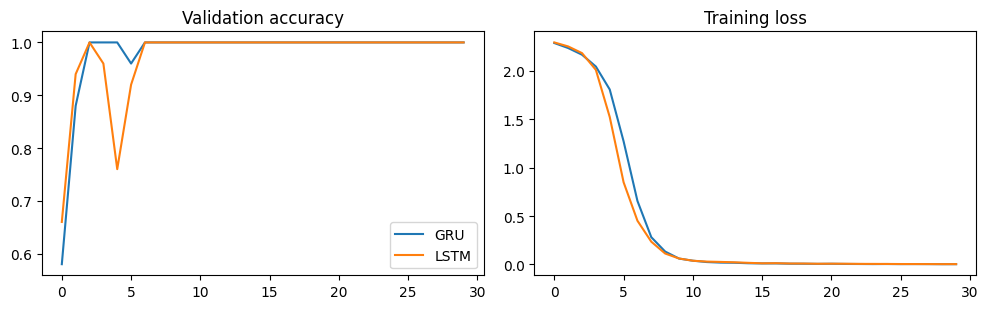

In [30]:
import os; os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
tf.random.set_seed(42)

tok = lambda s: re.findall(r"<t>|[a-z]+", s.lower())
classes = sorted(wsd.sense.unique()); c2i = {c: i for i, c in enumerate(classes)}

tr_df, te_df = train_test_split(wsd, test_size=0.2, stratify=wsd.sense, random_state=42)
vocab = {w: i + 2 for i, w in enumerate(sorted({w for s in tr_df.text for w in tok(s)}))}   # 0 = pad, 1 = unk
MAXLEN = max(len(tok(s)) for s in wsd.text)

def encode(texts):
    X = np.zeros((len(texts), MAXLEN), dtype="int32")
    for i, t in enumerate(texts):
        ids = [vocab.get(w, 1) for w in tok(t)][:MAXLEN]; X[i, :len(ids)] = ids
    return X

Xtr, ytr = encode(tr_df.text), tr_df.sense.map(c2i).values
Xte, yte = encode(te_df.text), te_df.sense.map(c2i).values

def build(cell):
    m = models.Sequential([
        layers.Embedding(len(vocab) + 2, 48, mask_zero=True),
        layers.Bidirectional(cell(48)),
        layers.Dropout(0.3),
        layers.Dense(len(classes), activation="softmax")])
    m.compile("adam", "sparse_categorical_crossentropy", metrics=["accuracy"])
    return m

histories, wsd_models = {}, {}
for name, cell in (("GRU", layers.GRU), ("LSTM", layers.LSTM)):
    m = build(cell)
    histories[name] = m.fit(Xtr, ytr, validation_data=(Xte, yte), epochs=30, batch_size=16, verbose=0)
    wsd_models[name] = m
    print(f"{name:5s} test accuracy: {m.evaluate(Xte, yte, verbose=0)[1]:.3f}   (params: {m.count_params():,})")

fig, ax = plt.subplots(1, 2, figsize=(10, 3.2))
for name, h in histories.items():
    ax[0].plot(h.history["val_accuracy"], label=name); ax[1].plot(h.history["loss"], label=name)
ax[0].set_title("Validation accuracy"); ax[1].set_title("Training loss"); ax[0].legend(); plt.tight_layout(); plt.show()

In [31]:
best = wsd_models["GRU"]
print(classification_report(yte, best.predict(Xte, verbose=0).argmax(1), target_names=classes, zero_division=0))

                 precision    recall  f1-score   support

      chip_food       1.00      1.00      1.00         5
      chip_tech       1.00      1.00      1.00         5
  date_calendar       1.00      1.00      1.00         5
     date_fruit       1.00      1.00      1.00         5
   pepper_spice       1.00      1.00      1.00         5
     pepper_veg       1.00      1.00      1.00         5
     roll_bread       1.00      1.00      1.00         5
      roll_verb       1.00      1.00      1.00         5
    stock_broth       1.00      1.00      1.00         5
stock_inventory       1.00      1.00      1.00         5

       accuracy                           1.00        50
      macro avg       1.00      1.00      1.00        50
   weighted avg       1.00      1.00      1.00        50



In [32]:
from nltk.wsd import lesk

def mark(sentence, target):
    return re.sub(rf"\b{target}\b", f"<t> {target}", sentence, count=1, flags=re.I)

def disambiguate(sentence, target, model="GRU"):
    p = wsd_models[model].predict(encode([mark(sentence, target)]), verbose=0)[0]
    allowed = [i for i, c in enumerate(classes) if c.startswith(target)]     # only senses of this word
    j = max(allowed, key=lambda i: p[i])
    return classes[j], float(p[j] / sum(p[i] for i in allowed))

novel = [("Chop the green pepper and toss it in the salad", "pepper"),
         ("Add a dash of pepper to the omelette", "pepper"),
         ("Keep a large stock of flour in the pantry", "stock"),
         ("Boil the chicken bones overnight to get a flavourful stock", "stock"),
         ("Look at the date on the yoghurt pot", "date"),
         ("Blend the date with milk for a smoothie", "date"),
         ("Roll the dough into a thin sheet", "roll"),
         ("I ate a cheese roll for lunch", "roll")]
out = []
for s, w in novel:
    g, pg = disambiguate(s, w, "GRU"); l, _ = disambiguate(s, w, "LSTM")
    syn = lesk(word_tokenize(s), w)
    out.append(dict(sentence=s, GRU=f"{g} ({pg:.2f})", LSTM=l, Lesk=(syn.definition()[:40] + "…") if syn else "-"))
pd.DataFrame(out)

,sentence,GRU,LSTM,Lesk
0,Chop the green pepper and toss it in the salad,pepper_veg (1.00),pepper_veg,sweet and hot varieties of fruits of pla…
1,Add a dash of pepper to the omelette,pepper_veg (0.73),pepper_spice,pungent seasoning from the berry of the …
2,Keep a large stock of flour in the pantry,stock_inventory (1.00),stock_inventory,a certificate documenting the shareholde…
3,Boil the chicken bones overnight to get a flavourful stock,stock_broth (1.00),stock_inventory,a plant or stem onto which a graft is ma…
4,Look at the date on the yoghurt pot,date_calendar (0.99),date_calendar,assign a date to; determine the (probabl…
5,Blend the date with milk for a smoothie,date_fruit (1.00),date_fruit,sweet edible fruit of the date palm with…
6,Roll the dough into a thin sheet,roll_verb (0.99),roll_verb,a long heavy sea wave as it advances tow…
7,I ate a cheese roll for lunch,roll_bread (0.96),roll_bread,a document that can be rolled up (as for…


The neural models use the *context of the sentence* and are trained for the cooking domain, while Lesk relies on WordNet glosses and often picks a general-English sense (e.g. `roll` → a sea wave or a roll of currency, `pepper` → a climbing vine). That is why a domain-trained GRU/LSTM is preferred inside the Recipe Analyzer.

---
# ★ Putting it all together — the `RecipeAnalyzer`
The class below wires the experiments into one pipeline and adds applications from Experiment 1: **text categorization** (predict the regional cuisine and the course of a dish), **summarization**, **sentiment analysis** (when a review is given) and **recommendation** (similar recipes). It is trained on the Indian recipes dataset.

In [33]:
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from nltk.sentiment.vader import SentimentIntensityAnalyzer

def extractive_summary(text, n=2):
    sents = sent_tokenize(text)
    prep = [preprocess(s, extra_stop=DOMAIN_STOP, pos_aware=False) for s in sents]
    freq = Counter(w for toks in prep for w in toks)
    scored = [(sum(freq[t] for t in toks) / (len(toks) + 1), i) for i, toks in enumerate(prep)]
    keep = sorted(i for _, i in sorted(scored, reverse=True)[:n])
    return " ".join(sents[i] for i in keep)

def count_steps(text):
    return len(re.findall(r"[.!?](?:\s|$)", text)) or 1

def difficulty_score(n_ing, n_steps, minutes):
    return 0.5 * n_ing + n_steps + min(minutes, 240) / 30

class RecipeAnalyzer:
    def __init__(self, data, test_size=0.2):
        self.data = data.reset_index(drop=True)
        self.sia = SentimentIntensityAnalyzer()
        self.texts = self.data["clean_text"].tolist()
        self.vec = TfidfVectorizer(ngram_range=(1, 2), min_df=3, max_df=0.5, sublinear_tf=True)
        self.M = self.vec.fit_transform(self.texts)
        self.clf, self.eval = {}, {}
        for target, min_count in (("region", 100), ("course", 200)):          # text categorisation
            counts = self.data[target].value_counts()
            keep = counts[counts >= min_count].index.difference(["Indian"] if target == "region" else [])
            idx = np.where(self.data[target].isin(keep))[0]
            tr, te = train_test_split(idx, test_size=test_size, stratify=self.data[target].values[idx], random_state=42)
            model = make_pipeline(TfidfVectorizer(ngram_range=(1, 2), min_df=3, max_df=0.5, max_features=40000, sublinear_tf=True),
                                  LogisticRegression(C=10, max_iter=300))
            model.fit([self.texts[i] for i in tr], self.data[target].values[tr])
            pred = model.predict([self.texts[i] for i in te])
            self.clf[target] = model
            self.eval[target] = dict(accuracy=accuracy_score(self.data[target].values[te], pred), y_true=self.data[target].values[te], y_pred=pred)
        scores = [difficulty_score(r.n_ingredients, r.n_steps, r.total_time) for r in self.data.itertuples()]
        self.cuts = np.quantile(scores, [0.33, 0.66])                        # difficulty = tertiles of the dataset

    def analyze(self, recipe, k_similar=5):
        steps = recipe["steps"]
        parsed = [parse_ingredient(l) for l in recipe["ingredients"]]
        prep = " ".join(preprocess("; ".join(recipe["ingredients"]) + ". " + steps, extra_stop=DOMAIN_STOP, pos_aware=False))
        ents = recipe_ner(steps)
        durations = [e for e, l in ents if l == "DURATION"]
        temps = [e for e, l in ents if l == "TEMPERATURE"]
        text_minutes = round(sum(to_minutes(d) for d in durations), 1)
        minutes = recipe.get("total_time") or text_minutes
        score = difficulty_score(len(parsed), count_steps(steps), minutes)
        sims = cosine_similarity(self.vec.transform([prep]), self.M)[0]
        order = [j for j in np.argsort(-sims) if j != recipe.get("idx")][:k_similar]
        preds = {}
        for target, model in self.clf.items():
            p = model.predict_proba([prep])[0]; top = np.argsort(-p)[:2]
            preds[target] = [(model.classes_[i], round(float(p[i]), 2)) for i in top]
        sent = self.sia.polarity_scores(recipe["review"])["compound"] if recipe.get("review") else None
        return dict(
            title=recipe["title"], ingredients=parsed, actions=extract_actions(steps),
            durations=durations, minutes_from_text=text_minutes, listed_minutes=recipe.get("total_time"),
            temperature=temps or None, equipment=sorted({e.lower() for e, l in ents if l == "EQUIPMENT"}),
            difficulty="Easy" if score < self.cuts[0] else "Medium" if score < self.cuts[1] else "Hard", difficulty_score=round(score, 1),
            region=preds["region"], course=preds["course"], summary=extractive_summary(steps, 2),
            sentiment=None if sent is None else ("Positive" if sent >= .05 else "Negative" if sent <= -.05 else "Neutral", round(sent, 2)),
            similar=[(self.data.dish_name[j], self.data.region[j], round(float(sims[j]), 2)) for j in order])

    def report(self, recipe, show_recipe=False):
        a = self.analyze(recipe)
        print(f"{'='*66}\n🍽  {a['title']}" + (f"   ({recipe['hindi_name']})" if recipe.get("hindi_name") else "") + f"\n{'='*66}")
        if recipe.get("english_desc") and recipe["english_desc"] != recipe["title"]: print("Also known as:", recipe["english_desc"])
        if recipe.get("region"): print(f"Listed as    : {recipe['region']} | {recipe.get('course')} | {recipe.get('diet')}")
        print("Predicted    : region =", ", ".join(f"{c} ({p})" for c, p in a["region"]), "| course =", ", ".join(f"{c} ({p})" for c, p in a["course"]))
        listed = f"{a['listed_minutes']} min listed, " if a["listed_minutes"] else ""
        print(f"Difficulty   : {a['difficulty']} (score {a['difficulty_score']})   Time: {listed}~{a['minutes_from_text']} min mentioned in the method   Temp: {a['temperature'] or 'n/a'}")
        print("Equipment    :", ", ".join(a["equipment"]) or "-")
        print("Actions      :", " → ".join(a["actions"]))
        if a["sentiment"]: print("Review       :", a["sentiment"])
        print("\nIngredients (parsed):")
        for i in a["ingredients"]:
            alias = f" [{i['alias']}]" if i["alias"] else ""
            print(f"  • {fmt_qty(i['quantity']):>6} {i['unit'] or '':<12} {i['name']}{alias}")
        if show_recipe:
            print("\nMethod:")
            for n, s in enumerate(sent_tokenize(recipe["steps"]), 1): print(f"  {n}. {s}")
        else:
            print("\nSummary      :", a["summary"])
        print("\nSimilar dishes:", "; ".join(f"{t} ({r}, {s})" for t, r, s in a["similar"]))
        return a

def fmt_qty(q):
    if q is None: return ""
    f = Fraction(q).limit_denominator(8)
    whole, rest = divmod(f.numerator, f.denominator)
    return " ".join(x for x in (str(whole) if whole else "", f"{rest}/{f.denominator}" if rest else "") if x) or "0"

def row_to_recipe(i):
    r = df.loc[i]
    return dict(idx=int(i), title=r.dish_name, english_desc=r.english_desc, hindi_name=r.hindi_name, region=r.region, course=r.course,
                diet=r.diet, total_time=int(r.total_time), ingredients=r.ingredients, steps=r.steps, review="")

analyzer = RecipeAnalyzer(df)
for t, e in analyzer.eval.items():
    print(f"{t:7s} classifier — held-out accuracy: {e['accuracy']:.2f}")
_ = analyzer.report(row_to_recipe(find_dishes("Palak Paneer", 1).index[0]))

region  classifier — held-out accuracy: 0.77
course  classifier — held-out accuracy: 0.68
🍽  Palak Paneer   (पालक पनीर)
Listed as    : Punjabi | Dinner | High Protein Vegetarian
Predicted    : region = North Indian (0.98), Bengali (0.01) | course = Dinner (0.72), Lunch (0.15)
Difficulty   : Medium (score 23.0)   Time: 60 min listed, ~18.5 min mentioned in the method   Temp: n/a
Equipment    : mixer grinder, pan, tadka
Actions      : cut → heat → boil → add → remove → pour → grind → puree → cook → mix → serve

Ingredients (parsed):
  •    250 grams        paneer
  •    500 grams        spinach
  •      1              tomato
  •      2 cloves       garlic
  •      2 inch         ginger
  •      2              green chillies
  •    1/2 tsp          cumin seeds
  •      1              tsp cinnamon powder
  •      1 tsp          cumin powder
  •    1/4 tsp          turmeric powder
  •      1 tsp          garam masala powder
  •      2 tbsp         cream
  •      1 tbsp         butter
  •   

### Try it on a recipe that is not in the dataset

In [34]:
new_recipe = dict(
    idx=None, title="Paneer Butter Masala", ingredients=["250 g Paneer (Indian cottage cheese) - cubed", "1 cup Tomato puree", "2 tbsp Butter",
    "1/2 cup Fresh cream", "1 teaspoon Garam masala", "1 teaspoon Kasuri methi (Dried fenugreek leaves)", "1 Onion - finely chopped"],
    steps="Heat butter in a kadhai and fry the chopped onion until golden. Add the tomato puree and garam masala and cook for 10 minutes. Stir in the cream and simmer gently for 5 minutes. Add the paneer and kasuri methi and cook for 3 more minutes. Garnish with cream and serve with naan.",
    review="Restaurant quality! Creamy, rich and absolutely delicious.")
_ = analyzer.report(new_recipe)

🍽  Paneer Butter Masala
Predicted    : region = North Indian (1.0), Bengali (0.0) | course = Dinner (0.69), Lunch (0.19)
Difficulty   : Easy (score 9.0)   Time: ~15.0 min mentioned in the method   Temp: n/a
Equipment    : kadhai
Actions      : heat → fry → chop → add → puree → cook → stir → simmer → garnish → serve
Review       : ('Positive', 0.84)

Ingredients (parsed):
  •    250 g            paneer [indian cottage cheese]
  •      1 cup          tomato puree
  •      2 tbsp         butter
  •    1/2 cup          cream
  •      1 teaspoon     garam masala
  •      1 teaspoon     kasuri methi [dried fenugreek leaves]
  •      1              onion

Summary      : Add the tomato puree and garam masala and cook for 10 minutes. Add the paneer and kasuri methi and cook for 3 more minutes.

Similar dishes: Tawa Paneer Masala (North Indian, 0.26); Cheesy Paneer Masala Curry (North Indian, 0.26); Butter Chicken (North Indian, 0.23); Restaurant Style Paneer Lababdar (North Indian, 0.23); Panee

### Evaluation of the text classifiers (held-out 20 %)

In [35]:
e = analyzer.eval["region"]
print(classification_report(e["y_true"], e["y_pred"], zero_division=0))
print("Overall accuracy is inflated by the two big classes (North / South Indian). Smaller regions have much lower recall because regional cuisines overlap heavily (Punjabi ⊂ North Indian, Chettinad ⊂ Tamil Nadu ⊂ South Indian) — a limit of bag-of-words features.")

sample_rows = df.sample(8, random_state=5).index
pd.DataFrame([{"dish": df.dish_name[i][:30], "region (listed)": df.region[i], "region (predicted)": a["region"][0][0],
               "course (predicted)": a["course"][0][0], "difficulty": a["difficulty"], "minutes in text": a["minutes_from_text"]}
              for i, a in ((i, analyzer.analyze(row_to_recipe(i))) for i in sample_rows)])

               precision    recall  f1-score   support

       Andhra       1.00      0.68      0.81        22
      Bengali       1.00      0.60      0.75        30
    Karnataka       0.87      0.48      0.62        27
       Kerala       0.85      0.63      0.72        27
Maharashtrian       0.86      0.61      0.72        31
 North Indian       0.78      0.95      0.85       154
 South Indian       0.67      0.87      0.75       113
   Tamil Nadu       0.67      0.15      0.24        27

     accuracy                           0.77       431
    macro avg       0.84      0.62      0.68       431
 weighted avg       0.78      0.77      0.75       431

Overall accuracy is inflated by the two big classes (North / South Indian). Smaller regions have much lower recall because regional cuisines overlap heavily (Punjabi ⊂ North Indian, Chettinad ⊂ Tamil Nadu ⊂ South Indian) — a limit of bag-of-words features.


,dish,region (listed),region (predicted),course (predicted),difficulty,minutes in text
0,Haryanvi Saag Gosht,Haryana,North Indian,Dinner,Medium,9.5
1,Iyengar Bakery Style Masala Br,Karnataka,Karnataka,Snack,Hard,1.0
2,Lehsuni Pudina Chutney,North Indian,North Indian,Side Dish,Easy,0.0
3,Patishapta Recipe (Rice Crepe),Bengali,Bengali,Dessert,Hard,10.0
4,Mulakootal (Vegetables In Coco,South Indian,South Indian,Lunch,Medium,9.5
5,Karnataka Style Jackfruit Moon,Coastal Karnataka,Karnataka,Dessert,Easy,0.0
6,Thatta Payaru Sambar,South Indian,South Indian,Lunch,Hard,2.5
7,Gajar Methi Sabzi Recipe (Carr,Indian,North Indian,Lunch,Medium,7.0


### ✍️ Interactive mode
Run the next cell to use the analyzer with your own input. A menu lets you

1. **type/paste your own recipe** (ingredients and steps line by line — press Enter on an empty line to finish a section),
2. **look up a dish by name** (Indian, English or Hindi, e.g. `rajma`, `masala dosa`, `बिरयानी`) and see its full recipe with the analysis,
3. **enter the ingredients you have** and get dishes you could cook,
4. quit.

In [36]:
def ask(prompt): return input(prompt).strip()

def read_lines(prompt):
    print(prompt)
    lines = []
    while True:
        line = ask("  > ")
        if not line: break
        lines.append(line)
    return lines

def read_recipe_from_user():
    title = ask("Recipe title: ") or "My Recipe"
    ingredients = read_lines("\nIngredients — one per line, e.g. '2 cups Rice' (empty line to finish):")
    step_lines = read_lines("\nCooking steps — type or paste the method (empty line to finish):")
    steps = " ".join(l if l[-1] in ".!?" else l + "." for l in step_lines)
    review = ask("\nReview / comment (optional, Enter to skip): ")
    if not ingredients or not steps:
        print("\n⚠️  Please enter at least one ingredient and one cooking step.")
        return None
    return dict(idx=None, title=title, ingredients=ingredients, steps=steps, review=review)

def choose_from(hits):
    if hits is None or len(hits) == 0:
        print("Nothing found — try another spelling or fewer words."); return
    print()
    for n, (i, r) in enumerate(hits.iterrows(), 1):
        extra = f" — {r['uses']}" if "uses" in hits else ""
        print(f"  {n}. {r.dish_name} ({r.region}, {r.course}){' | ' + r.hindi_name if r.hindi_name else ''}{extra}")
    pick = ask("\nType a number to open that recipe (Enter to go back): ")
    if pick.isdigit() and 1 <= int(pick) <= len(hits):
        print(); analyzer.report(row_to_recipe(hits.index[int(pick) - 1]), show_recipe=True)

MENU = """
==================== 🍳 RECIPE ANALYZER ====================
 1) Analyze my own recipe
 2) Look up a dish by name (Indian / English / Hindi)
 3) What can I cook with the ingredients I have?
 4) Quit"""
while True:
    print(MENU)
    choice = ask("Choose 1-4: ")
    if choice == "1":
        r = read_recipe_from_user()
        if r: print(); analyzer.report(r)
    elif choice == "2":
        choose_from(find_dishes(ask("Dish name: "), 5))
    elif choice == "3":
        choose_from(recipes_by_ingredients(ask("Ingredients you have (comma-separated): "), 5))
    elif choice == "4":
        print("Done — happy cooking! 🍲"); break
    else:
        print("Please type 1, 2, 3 or 4.")


==================== 🍳 RECIPE ANALYZER ====================
 1) Analyze my own recipe
 2) Look up a dish by name (Indian / English / Hindi)
 3) What can I cook with the ingredients I have?
 4) Quit
Choose 1-4: 1
Recipe title: aloo vadi

Ingredients — one per line, e.g. '2 cups Rice' (empty line to finish):
  > Colocasia Leaves
  > Calcium oxalate in the colocasia leaves tends to cause itching in the mouth and throat if not cooked properly. So, it is important to choose and cook the leaves the right way. You can find colocasia leaves in any Indian or Asian grocery store. 
  > Gram flour / Besan – makes up the base of the marinade that is applied to the leaves. This golden-hued flour will act as a binding agent in making the colocasia leaves in rolls. Also, it provides the alu vadi with the necessary crispness. 
  > Tamarind paste – is a very important ingredient in this recipe. Adding something tangy while making alu vadi is a must. The addition of tamarind paste in the marinade helps 

In [37]:
# ================= Recipe Analyzer — interactive UI (ipywidgets) =================
# Run this AFTER all earlier cells (it uses: analyzer, df, find_dishes, recipes_by_ingredients, row_to_recipe).
# First time only (not needed on Colab):  !pip install -q ipywidgets
import ipywidgets as widgets
from IPython.display import display, clear_output

FULL = widgets.Layout(width="98%")
STYLE = {"description_width": "110px"}

def _safe(out, fn):
    """run fn() inside an Output widget and show errors nicely"""
    with out:
        clear_output(wait=True)
        try:
            fn()
        except Exception as e:
            print(f"⚠️  {type(e).__name__}: {e}")

def _options(hits):
    return [(f"{r.dish_name[:60]}  —  {r.region}, {r.course}", int(i)) for i, r in hits.iterrows()]

# ------------------------------------------------------------------ Tab 1: analyze my own recipe
t1_title  = widgets.Text(description="Recipe title", placeholder="e.g. Paneer Butter Masala", layout=FULL, style=STYLE)
t1_ing    = widgets.Textarea(description="Ingredients", placeholder="One per line, e.g.\n2 cups Rice\n1 tbsp Ghee\nSalt", layout=widgets.Layout(width="98%", height="130px"), style=STYLE)
t1_steps  = widgets.Textarea(description="Method", placeholder="One step per line, or paste the whole method", layout=widgets.Layout(width="98%", height="150px"), style=STYLE)
t1_review = widgets.Text(description="Review (opt.)", placeholder="optional comment -> sentiment analysis", layout=FULL, style=STYLE)
t1_go     = widgets.Button(description="Analyze recipe", button_style="success", icon="search")
t1_ex     = widgets.Button(description="Load example", icon="file-text-o")
t1_clear  = widgets.Button(description="Clear", icon="trash")
t1_out    = widgets.Output()

def _load_example(_):
    t1_title.value = "Paneer Butter Masala"
    t1_ing.value = "\n".join(new_recipe["ingredients"]) if "new_recipe" in globals() else "250 g Paneer - cubed\n1 cup Tomato puree\n2 tbsp Butter\n1/2 cup Fresh cream\n1 teaspoon Garam masala\n1 Onion - finely chopped"
    t1_steps.value = ("Heat butter in a kadhai and fry the chopped onion until golden.\nAdd the tomato puree and garam masala and cook for 10 minutes.\n"
                      "Stir in the cream and simmer gently for 5 minutes.\nAdd the paneer and cook for 3 more minutes.\nGarnish with cream and serve with naan.")
    t1_review.value = "Restaurant quality! Creamy, rich and absolutely delicious."

def _clear_t1(_):
    t1_title.value = t1_ing.value = t1_steps.value = t1_review.value = ""
    with t1_out: clear_output()

def _analyze_own(_):
    def run():
        ings  = [l.strip() for l in t1_ing.value.splitlines() if l.strip()]
        lines = [l.strip() for l in t1_steps.value.splitlines() if l.strip()]
        if not ings or not lines:
            print("⚠️  Please enter at least one ingredient and one cooking step."); return
        steps = " ".join(l if l[-1] in ".!?" else l + "." for l in lines)
        analyzer.report(dict(idx=None, title=t1_title.value.strip() or "My Recipe", ingredients=ings,
                             steps=steps, review=t1_review.value.strip()))
    _safe(t1_out, run)

t1_go.on_click(_analyze_own); t1_ex.on_click(_load_example); t1_clear.on_click(_clear_t1)
tab1 = widgets.VBox([t1_title, t1_ing, t1_steps, t1_review, widgets.HBox([t1_go, t1_ex, t1_clear]), t1_out])

# ------------------------------------------------------------------ Tab 2: look up a dish by name
t2_q    = widgets.Text(description="Dish name", placeholder="rajma, masala dosa, aar macher jhol, बिरयानी …", layout=FULL, style=STYLE)
t2_go   = widgets.Button(description="Search", button_style="primary", icon="search")
t2_dd   = widgets.Dropdown(description="Results", options=[], layout=FULL, style=STYLE)
t2_open = widgets.Button(description="Open recipe + analysis", button_style="success", icon="book")
t2_out  = widgets.Output()

def _search_dish(_):
    def run():
        if not t2_q.value.strip():
            print("Type a dish name first."); return
        hits = find_dishes(t2_q.value, 8)
        t2_dd.options = _options(hits)
        t2_dd.index = 0 if len(hits) else None      # select the first result
        display(hits[["dish_name", "region", "course", "match"]].reset_index(drop=True))
        print("Pick a dish in the 'Results' list and press 'Open recipe + analysis'.")
    _safe(t2_out, run)

def _open_dish(_):
    _safe(t2_out, lambda: analyzer.report(row_to_recipe(t2_dd.value), show_recipe=True) if t2_dd.value is not None
          else print("Search for a dish first."))

t2_go.on_click(_search_dish); t2_open.on_click(_open_dish)
tab2 = widgets.VBox([t2_q, widgets.HBox([t2_go]), t2_dd, t2_open, t2_out])

# ------------------------------------------------------------------ Tab 3: what can I cook with...
t3_q    = widgets.Text(description="I have", placeholder="paneer, tomato, onion, cream  (typos are fixed automatically)", layout=FULL, style=STYLE)
t3_go   = widgets.Button(description="Find dishes", button_style="primary", icon="cutlery")
t3_dd   = widgets.Dropdown(description="Results", options=[], layout=FULL, style=STYLE)
t3_open = widgets.Button(description="Open recipe + analysis", button_style="success", icon="book")
t3_out  = widgets.Output()

def _find_by_ingredients(_):
    def run():
        if not t3_q.value.strip():
            print("List a few ingredients first."); return
        hits = recipes_by_ingredients(t3_q.value, 8)
        if len(hits) == 0:
            print("No known ingredient found — check the spelling."); return
        t3_dd.options = _options(hits)
        t3_dd.index = 0 if len(hits) else None      # select the first result
        display(hits[["dish_name", "region", "course", "uses", "other_ingredients"]].reset_index(drop=True))
        print("Pick a dish in the 'Results' list and press 'Open recipe + analysis'.")
    _safe(t3_out, run)

def _open_dish3(_):
    _safe(t3_out, lambda: analyzer.report(row_to_recipe(t3_dd.value), show_recipe=True) if t3_dd.value is not None
          else print("Search first."))

t3_go.on_click(_find_by_ingredients); t3_open.on_click(_open_dish3)
tab3 = widgets.VBox([t3_q, widgets.HBox([t3_go]), t3_dd, t3_open, t3_out])

# ------------------------------------------------------------------ assemble
tabs = widgets.Tab(children=[tab1, tab2, tab3])
for i, name in enumerate(["✍️ Analyze my recipe", "🔎 Find a dish", "🥘 What can I cook?"]):
    tabs.set_title(i, name)
header = widgets.HTML("<h2 style='margin:4px 0'>🍳 Recipe Analyzer</h2>"
                      f"<div style='color:#666'>{len(df):,} Indian recipes · {df.region.nunique()} regional cuisines</div>")
display(widgets.VBox([header, tabs]))